In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats

from math import sqrt
from sklearn.model_selection import KFold, cross_val_score

import optuna
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings('ignore')

pd.pandas.set_option('display.max_columns', None)

In [6]:
filepath=r"C:\Users\Lenovo\ML Sprint folder\HousePrice\train.csv"
train =pd.read_csv(filepath)
filepath=r"C:\Users\Lenovo\ML Sprint folder\HousePrice\test.csv"
test=pd.read_csv(filepath)
filepath=r"C:\Users\Lenovo\ML Sprint folder\HousePrice\sample_submission.csv"
sample_submission = pd.read_csv(filepath)
print("train data shape is {}".format(train.shape))
print("test data shape is {}".format(test.shape))
print("sample_submission data shape is {}".format(sample_submission.shape))


train data shape is (1460, 81)
test data shape is (1459, 80)
sample_submission data shape is (1459, 2)


In [7]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [8]:
train.duplicated().sum()

np.int64(0)

Target Feature distribution

Find out the distribution of the target feature

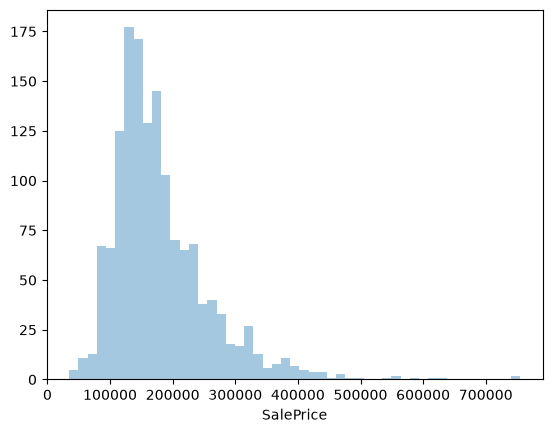

In [9]:
sns.distplot(train.get('SalePrice'), kde=False)
plt.show()

The dependent feature 'SalePrice' is right-skewed, we will have to perform a log-normal transformation on this feature.

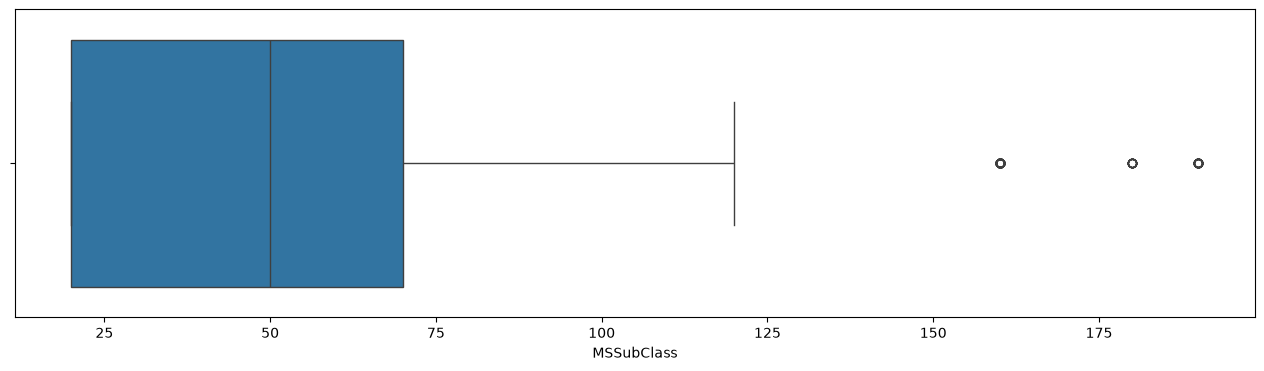

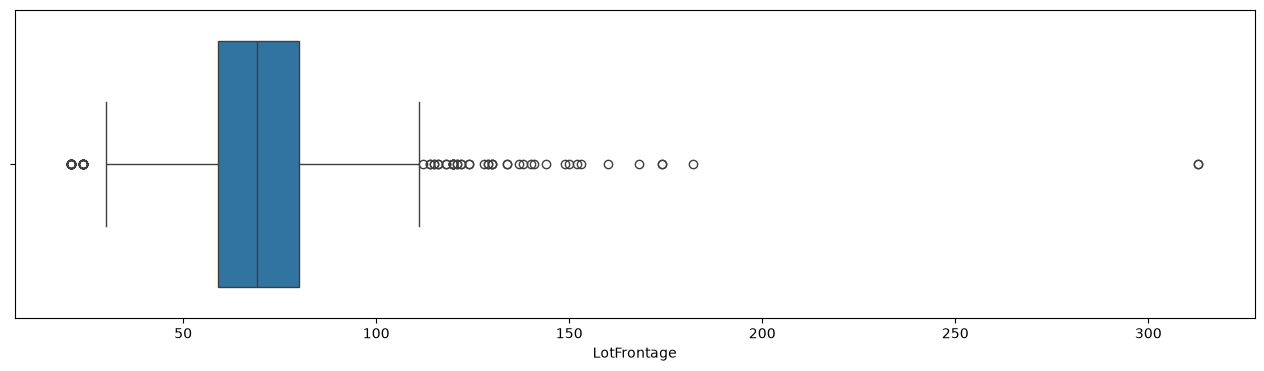

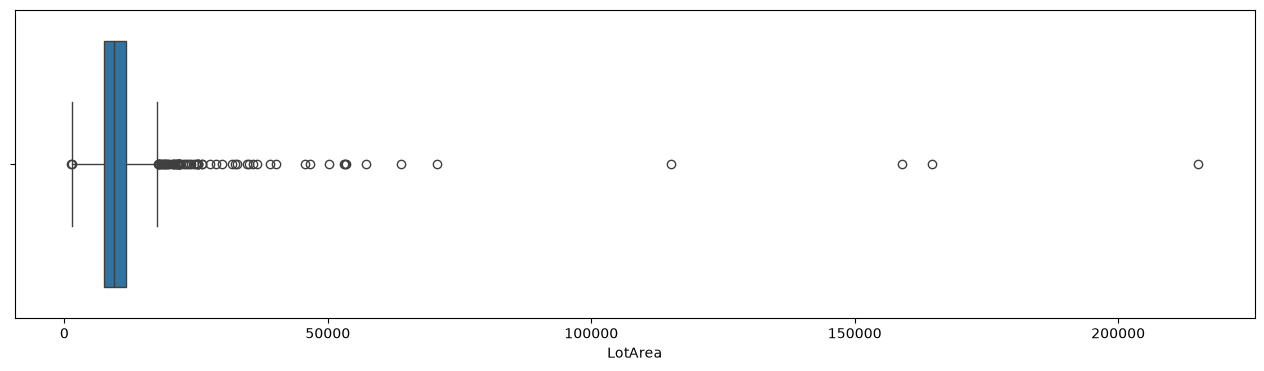

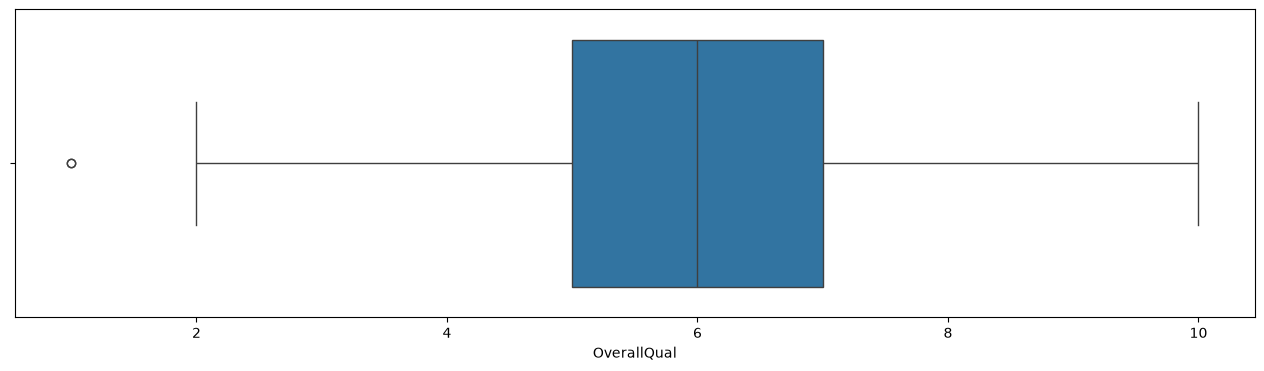

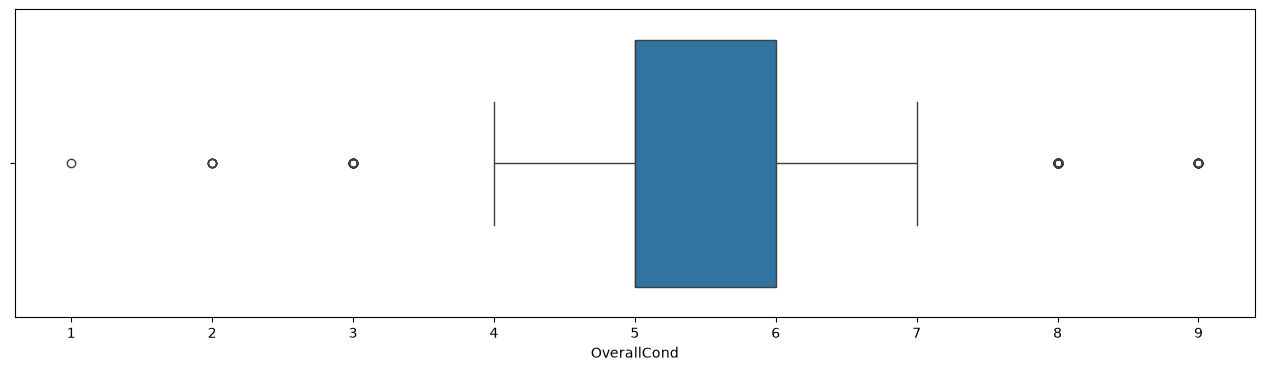

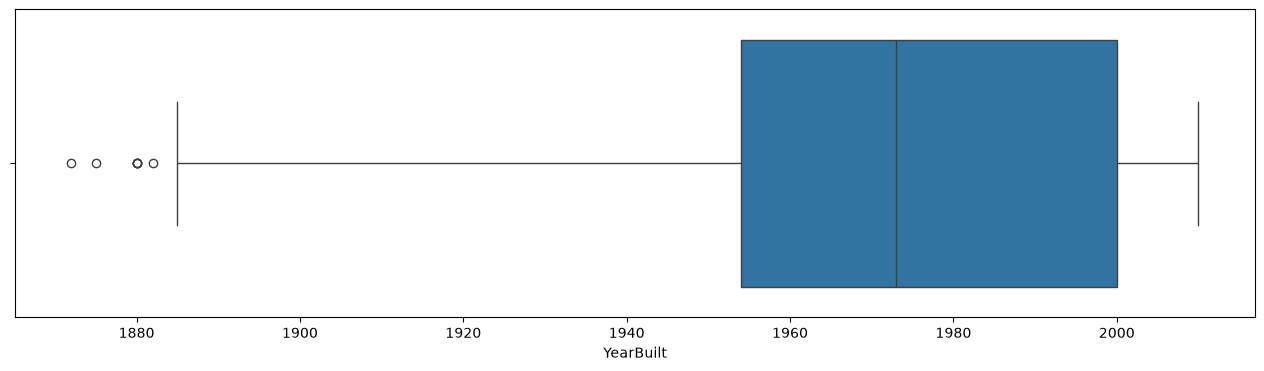

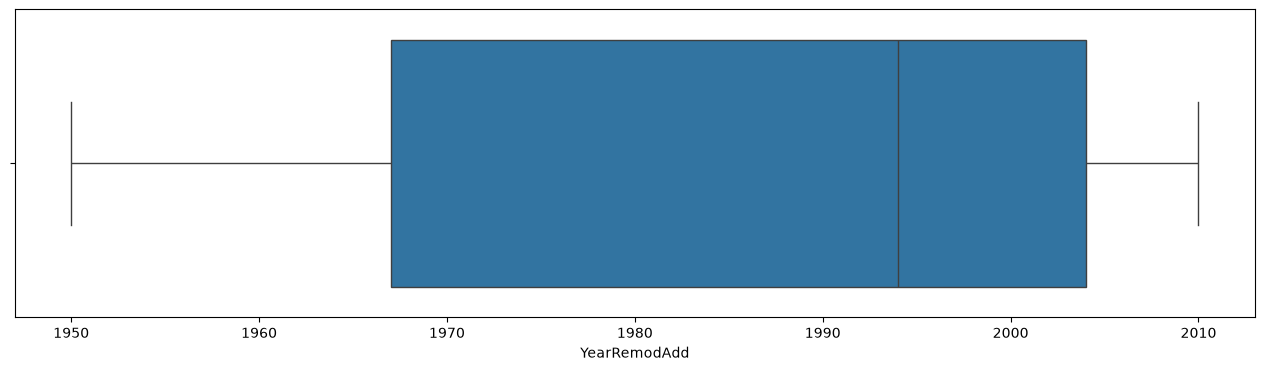

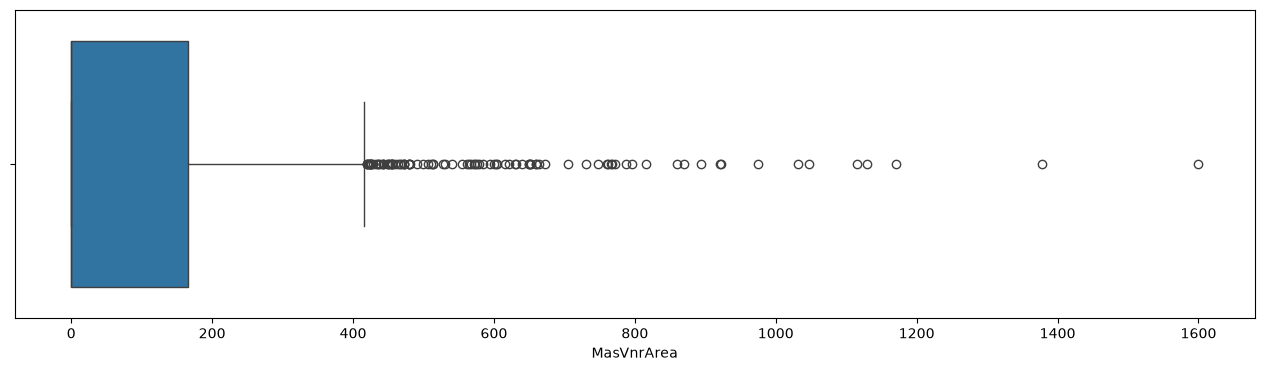

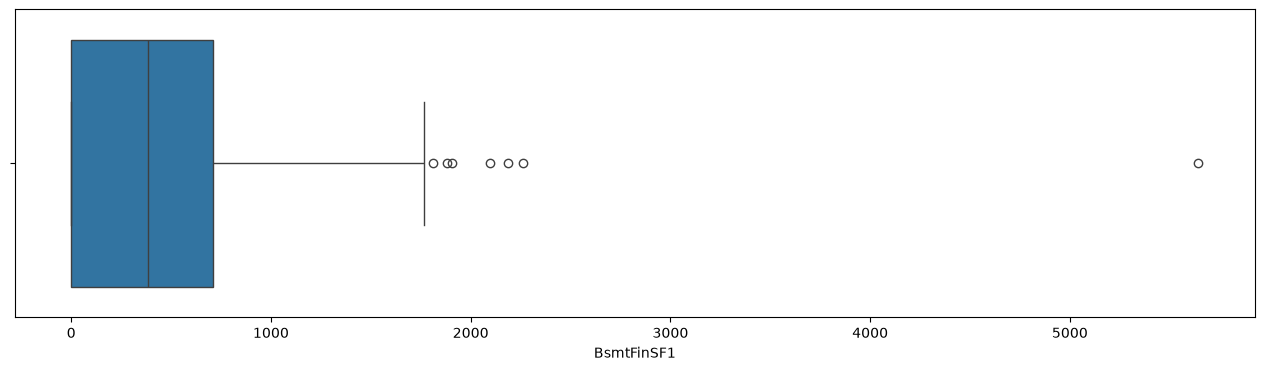

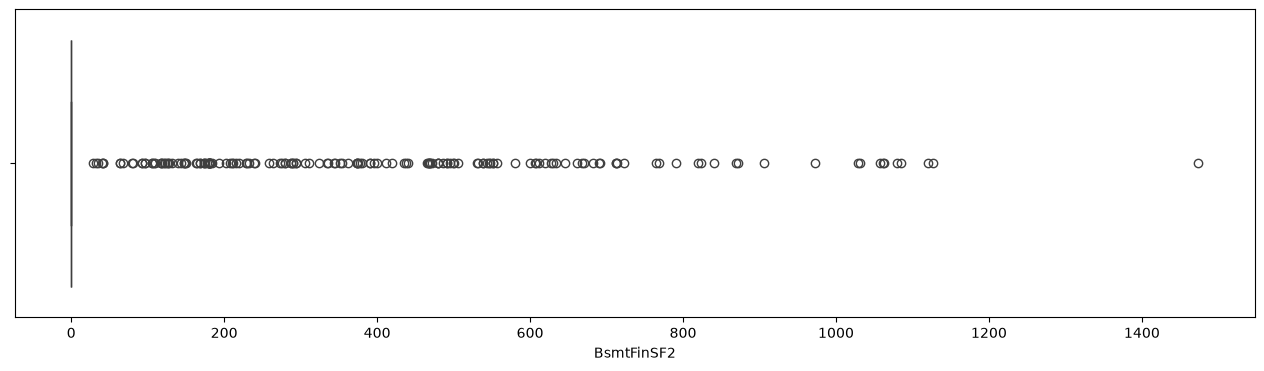

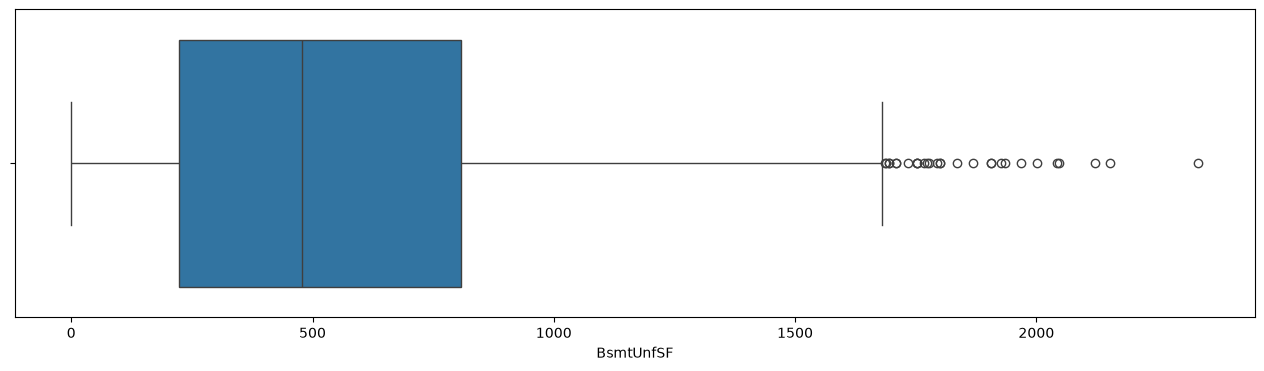

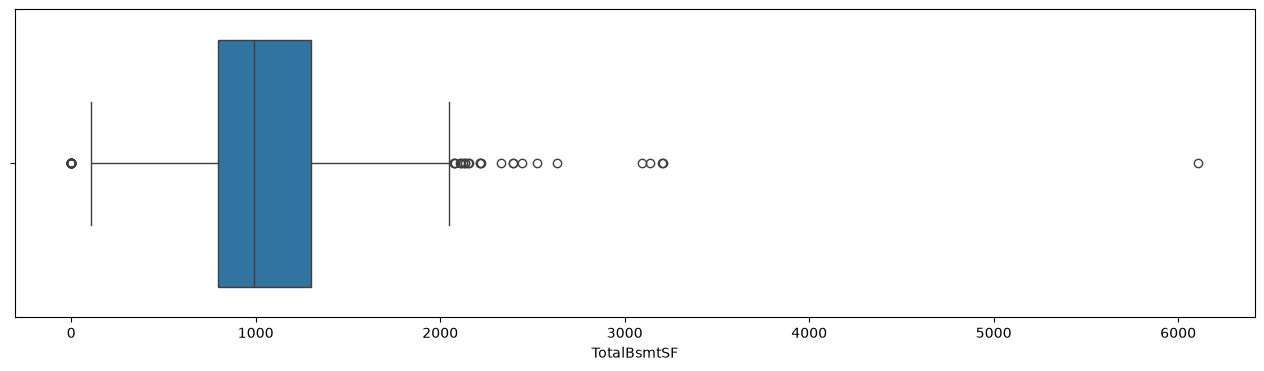

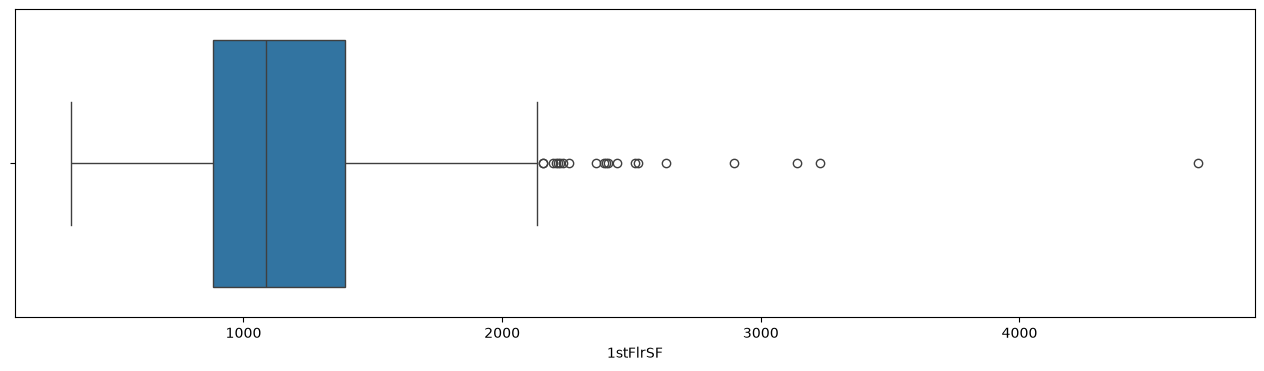

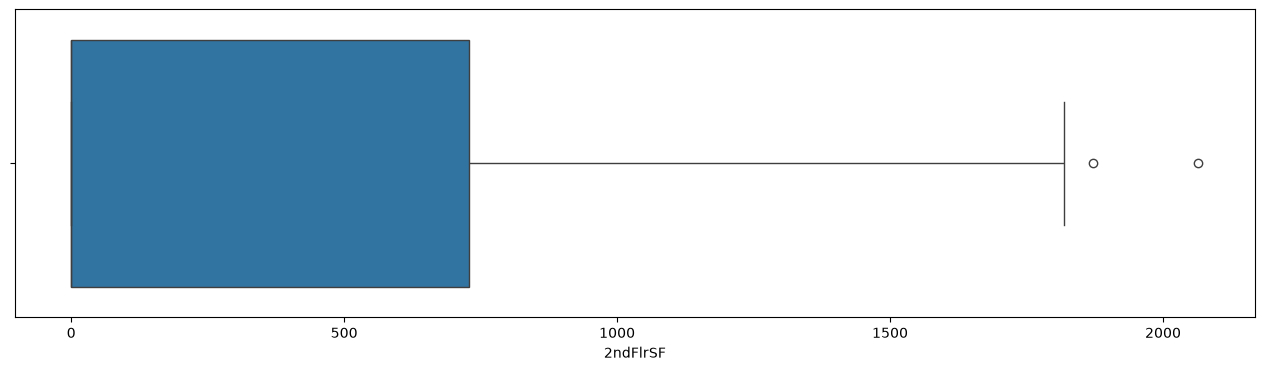

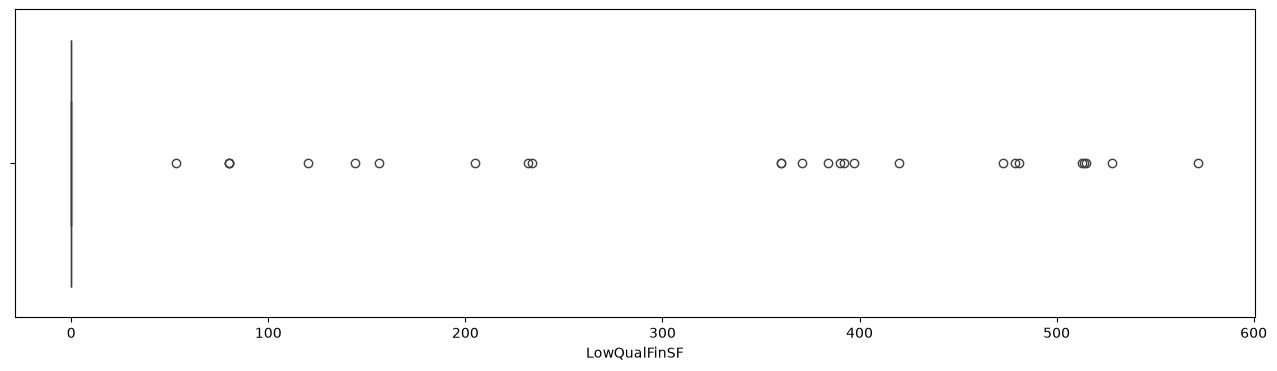

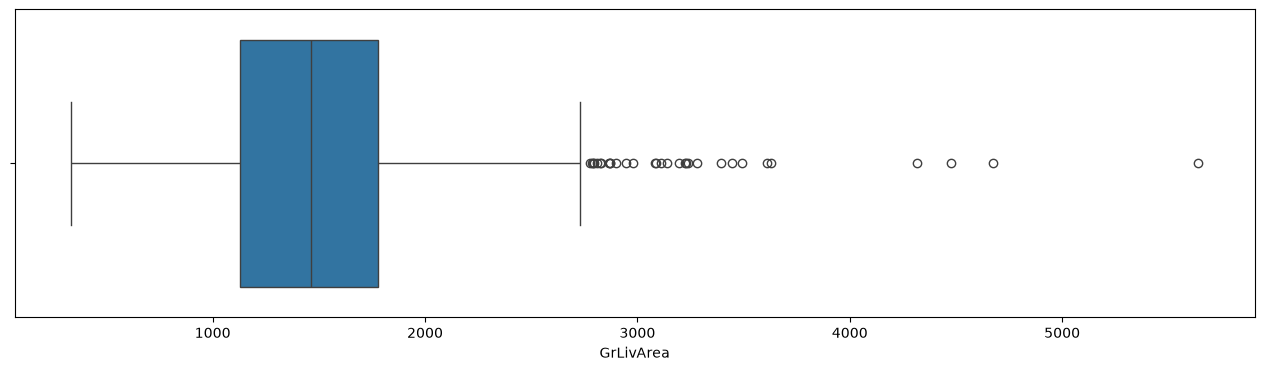

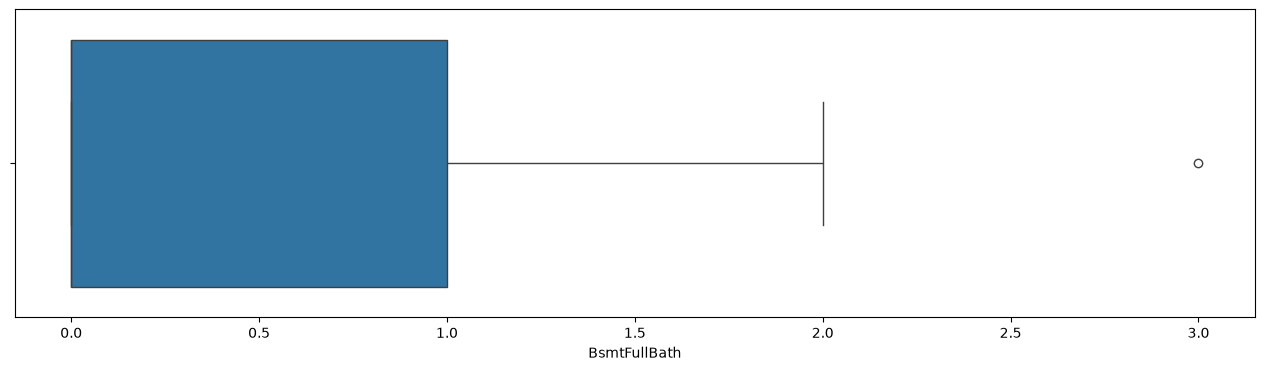

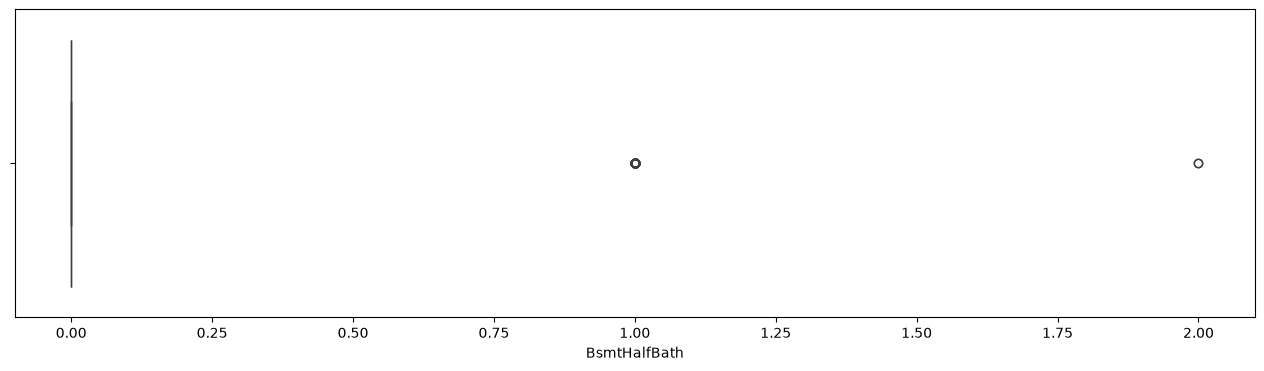

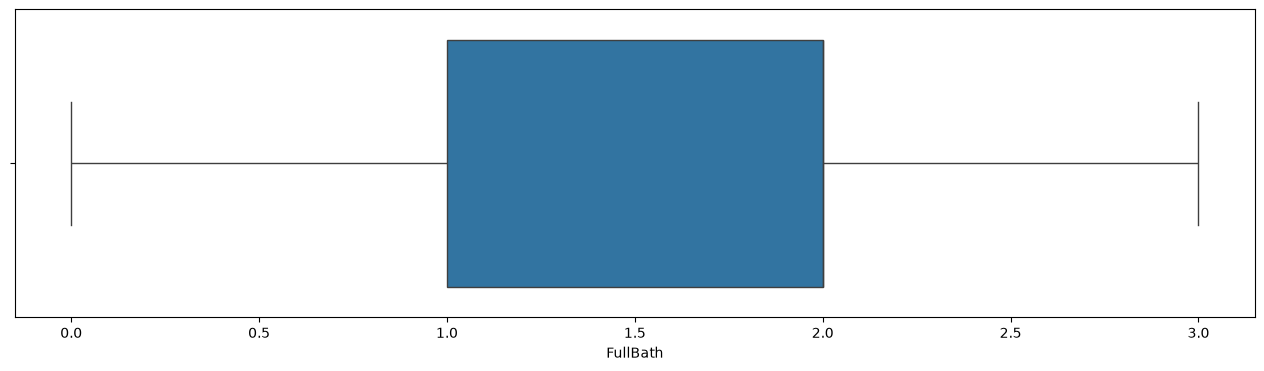

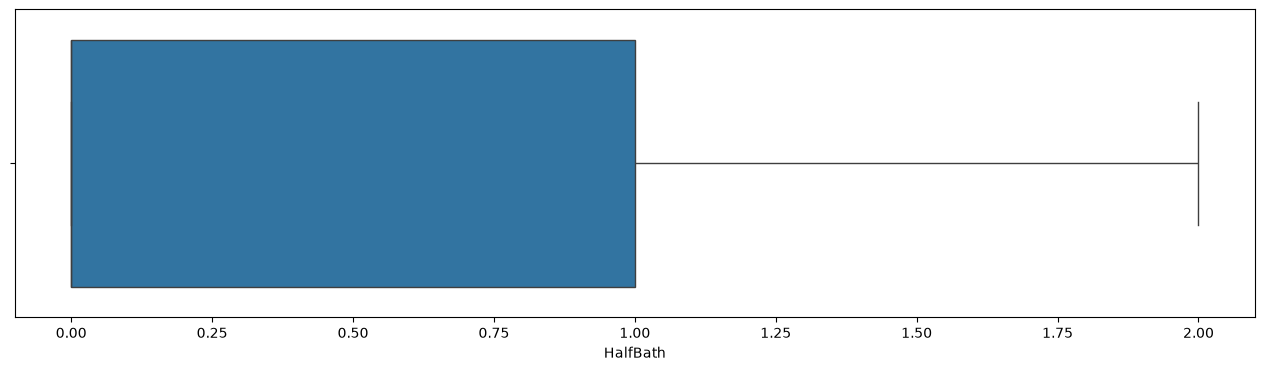

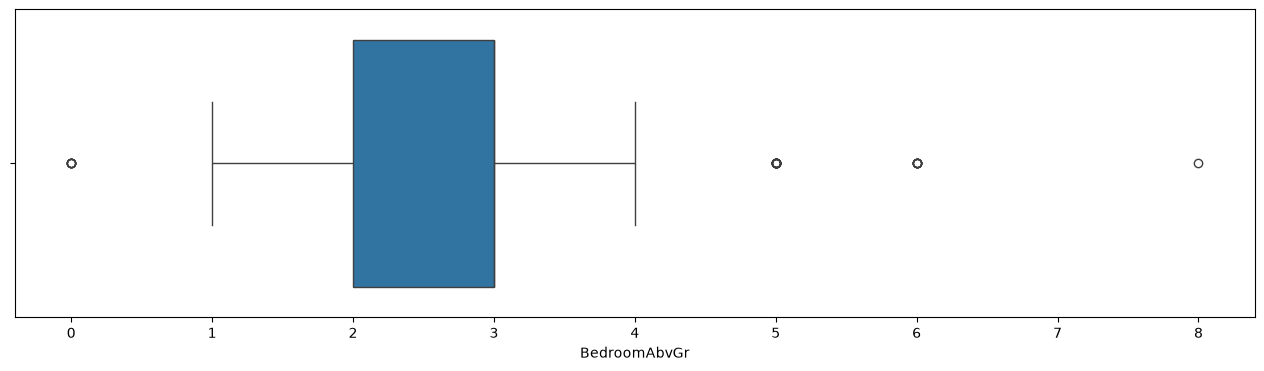

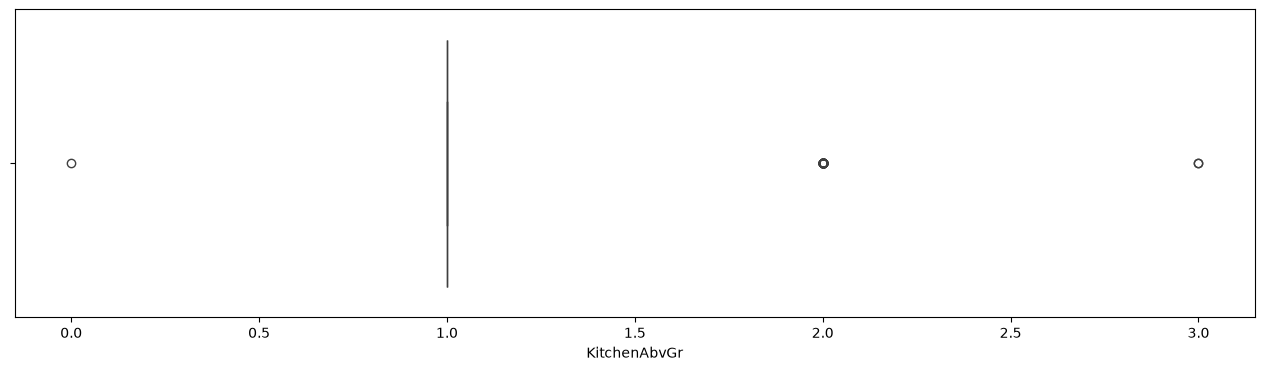

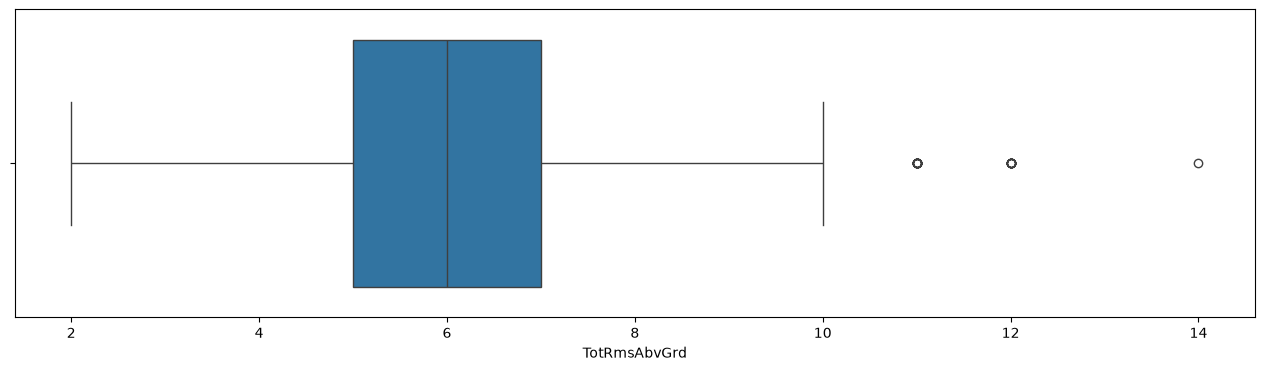

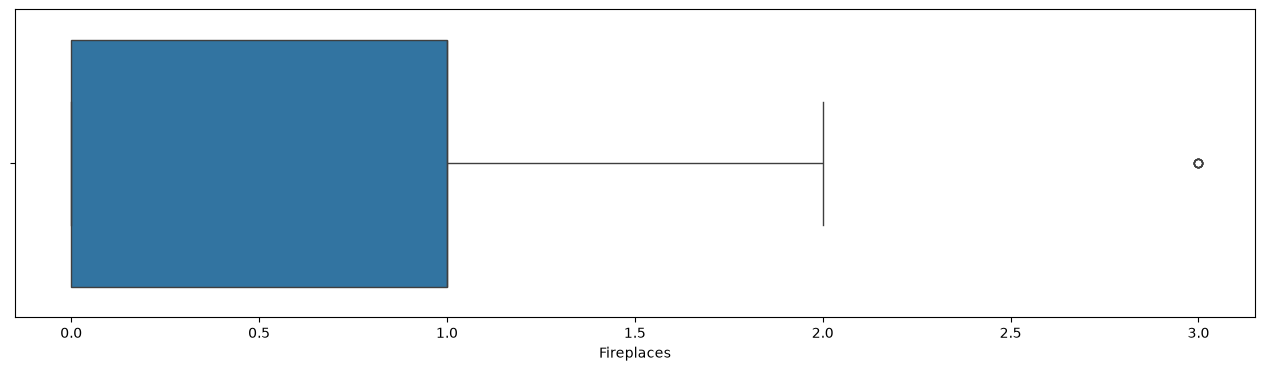

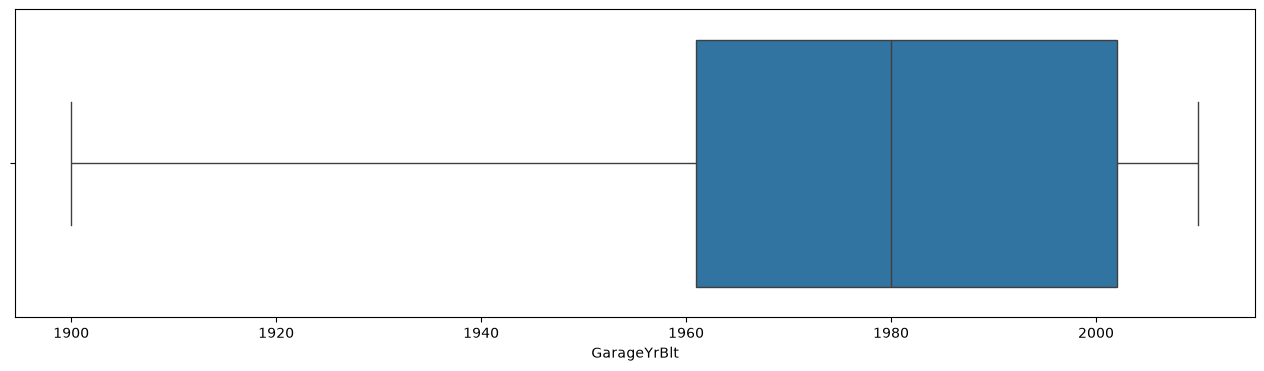

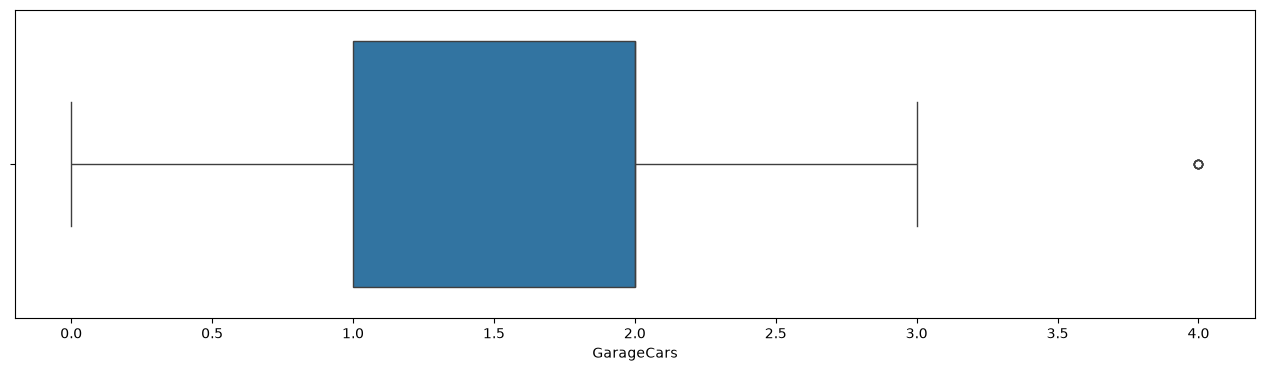

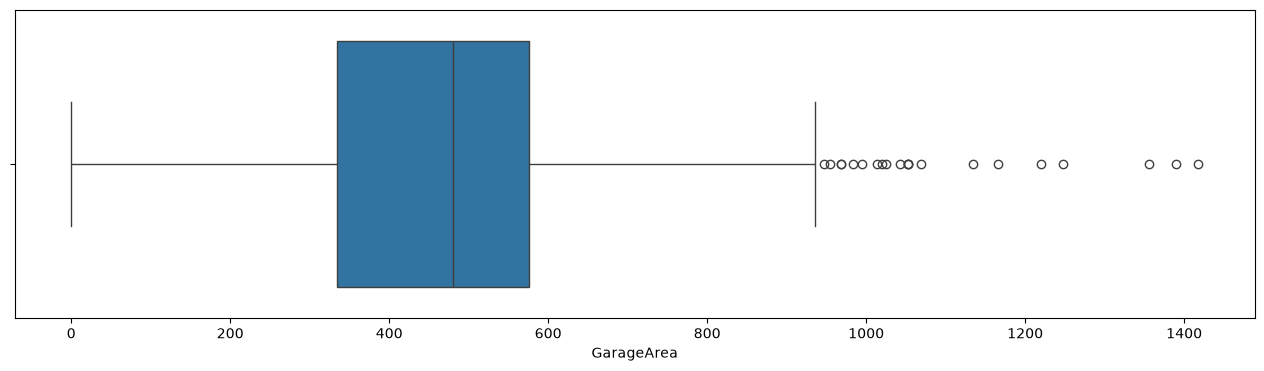

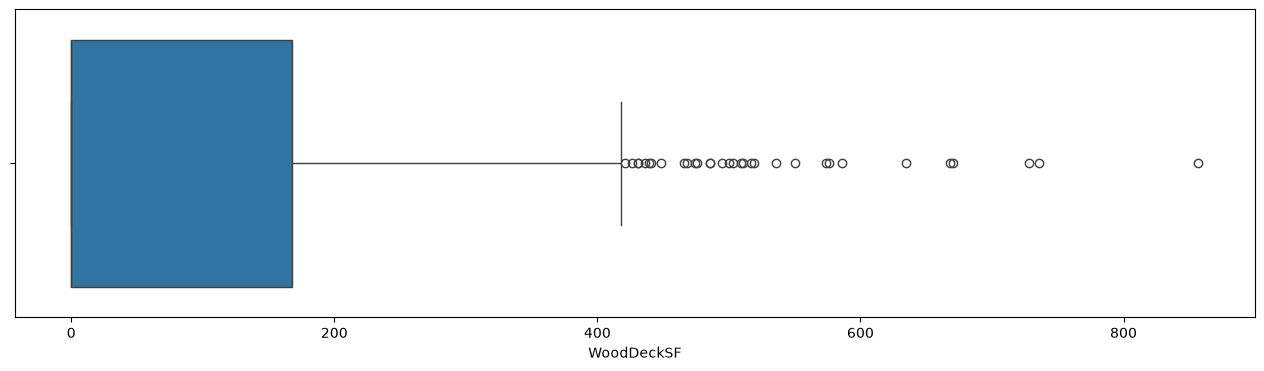

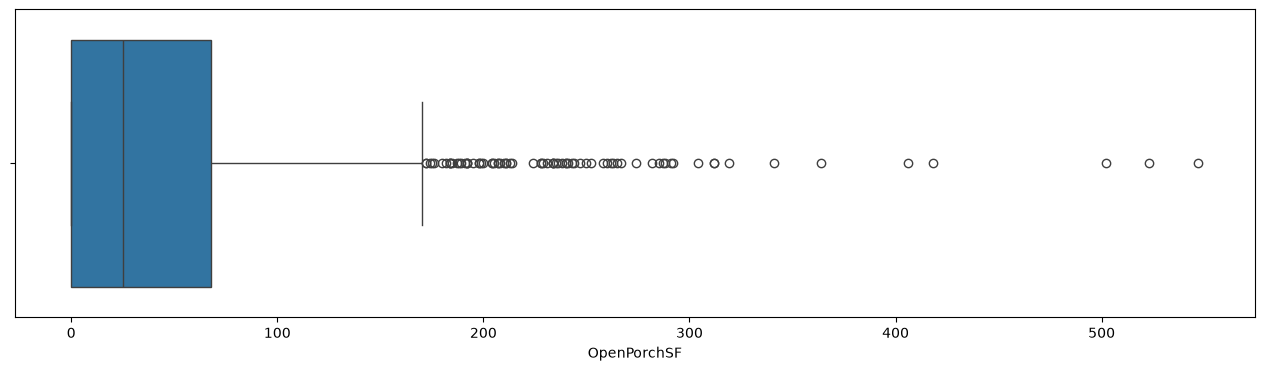

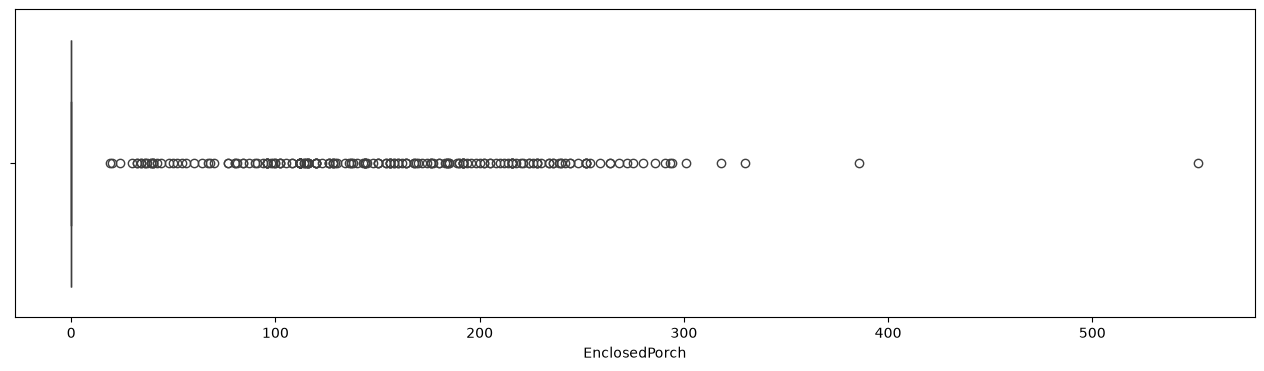

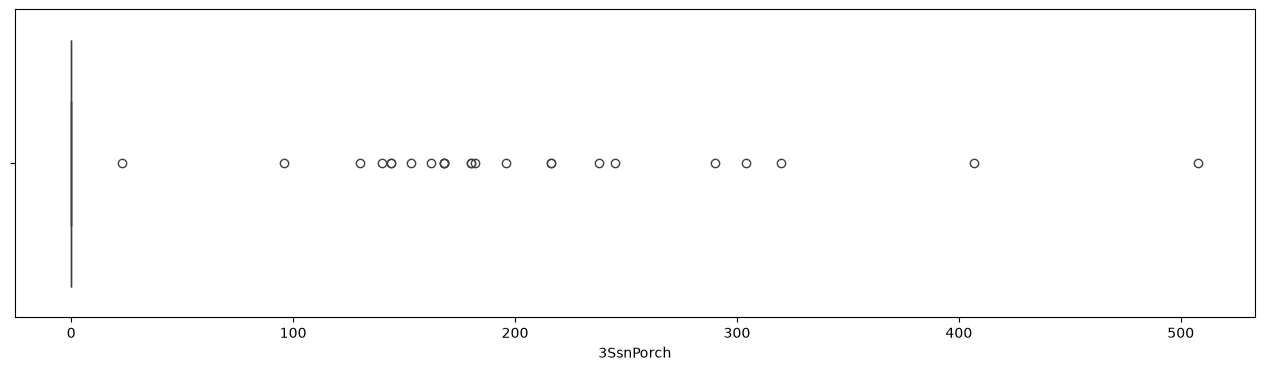

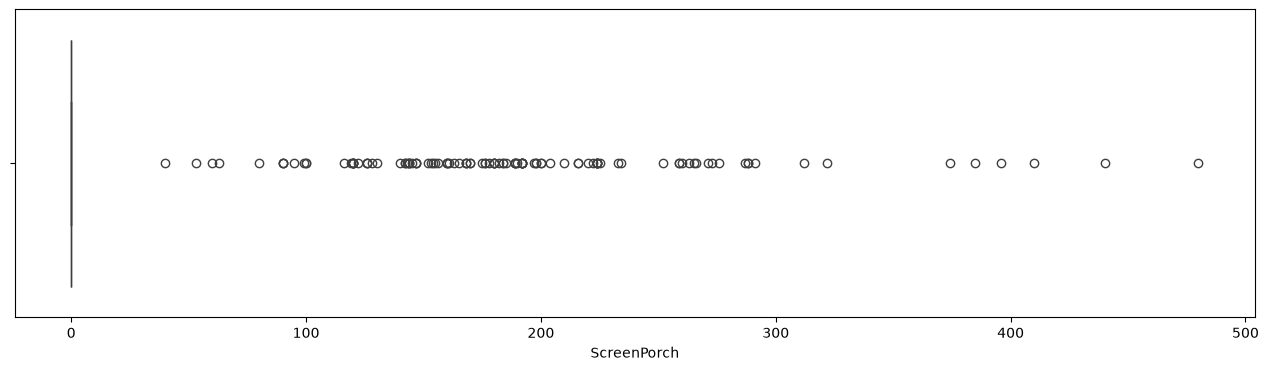

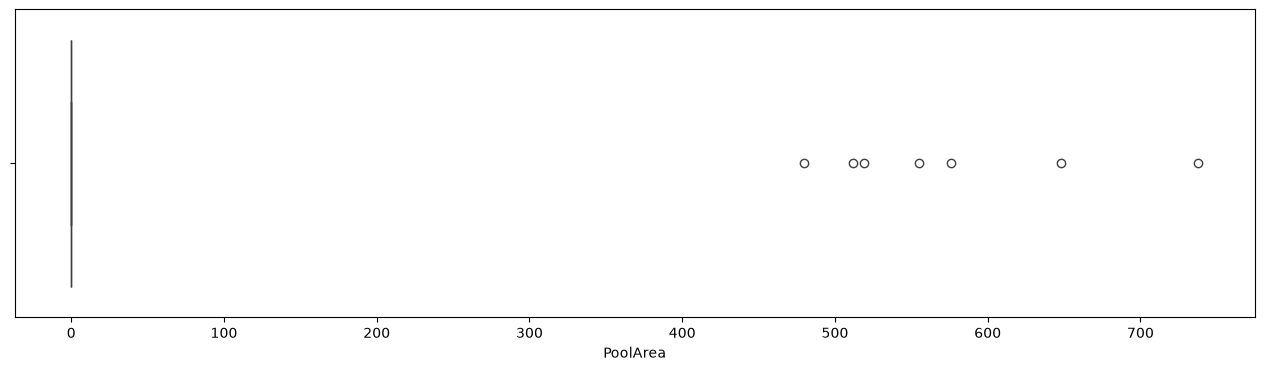

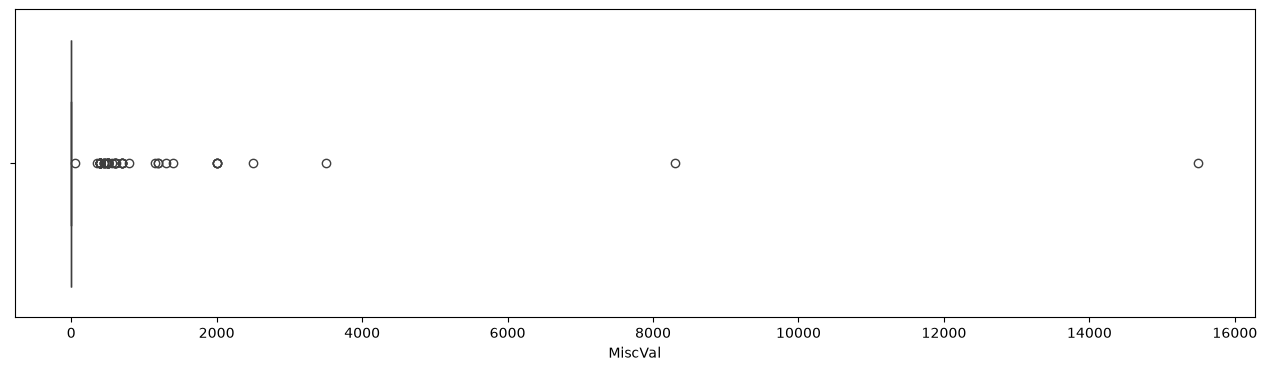

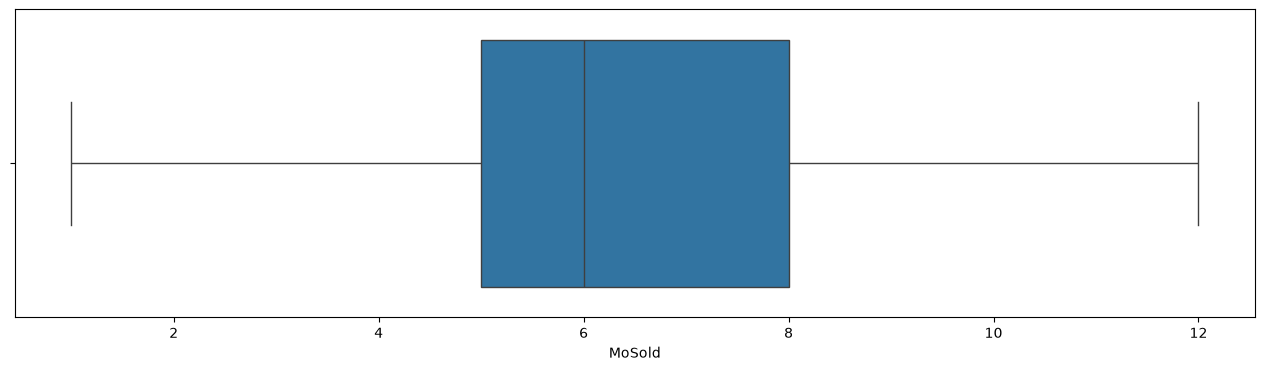

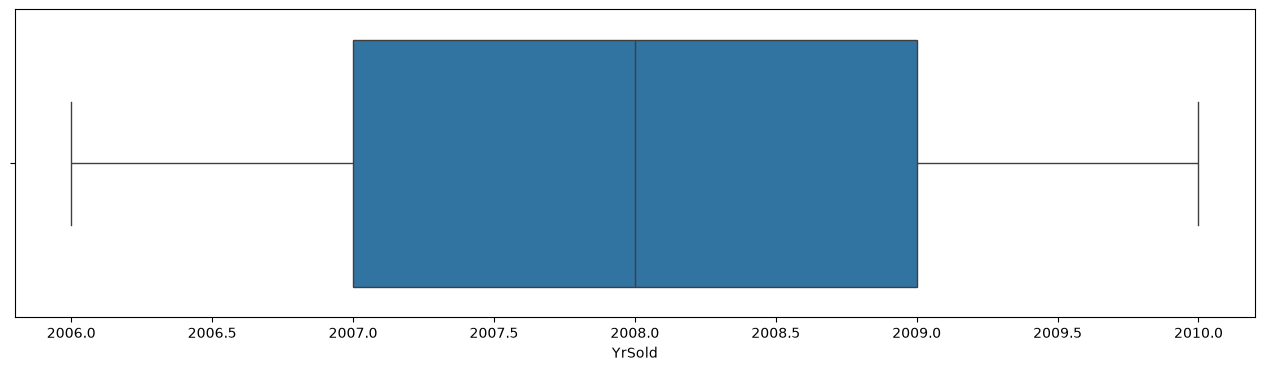

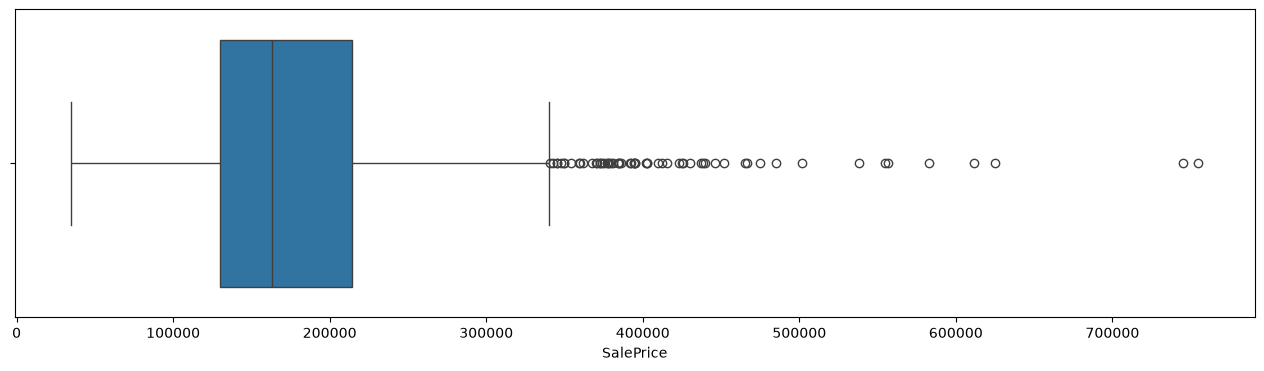

In [10]:
numerical_df=train.select_dtypes(exclude=['object'])
numerical_df=numerical_df.drop(['Id'],axis=1)

for column in numerical_df:
    plt.figure(figsize=(16, 4))
    # sns.set_theme(style='whitegrid')
    sns.boxplot(numerical_df[column], orient='h')
    plt.xlabel(column)
    plt.show()

From the images above, it can be inferred that there are outliers in the data. We will not delete the rows containing the outliers for the changes that it might destroy some important data. The outliers will have to be handled later.

# Merge the datasets

Combine the two datasets to do the pre-processing on before splitting it up again for the models

In [11]:
df=pd.concat([train,test])
df.reset_index(drop=True,inplace=True)
df.shape

(2919, 81)

## Fill in Missing Data

Go through each feature and fill in the missing data.

Numerical:

->Fill in missing data with either 0 (which represents "None"), the mean or the mode, whichever makes more sense. Except for SalePrice.

Categorical:

->Fill in the data with "None" if it seems that it makes sense. Otherwise, fill it in with the mode.

In [12]:
df.isnull().sum().sort_values(ascending=False).head(40)

PoolQC          2909
MiscFeature     2814
Alley           2721
Fence           2348
MasVnrType      1766
SalePrice       1459
FireplaceQu     1420
LotFrontage      486
GarageCond       159
GarageYrBlt      159
GarageFinish     159
GarageQual       159
GarageType       157
BsmtExposure      82
BsmtCond          82
BsmtQual          81
BsmtFinType2      80
BsmtFinType1      79
MasVnrArea        23
MSZoning           4
Functional         2
BsmtFullBath       2
Utilities          2
BsmtHalfBath       2
SaleType           1
BsmtFinSF2         1
BsmtFinSF1         1
TotalBsmtSF        1
BsmtUnfSF          1
Exterior2nd        1
KitchenQual        1
GarageCars         1
GarageArea         1
Electrical         1
Exterior1st        1
HouseStyle         0
Condition1         0
Neighborhood       0
BldgType           0
Condition2         0
dtype: int64

In [13]:
print(df['PoolQC'].unique())
print("")
print(df['PoolQC'].value_counts())

<StringArray>
[nan, 'Ex', 'Fa', 'Gd']
Length: 4, dtype: str

PoolQC
Ex    4
Gd    4
Fa    2
Name: count, dtype: int64


In [14]:
df['PoolQC']=df['PoolQC'].fillna('None',inplace=True)


In [15]:
print(df['MiscFeature'].unique())
print("")
print(df['MiscFeature'].value_counts())

<StringArray>
[nan, 'Shed', 'Gar2', 'Othr', 'TenC']
Length: 5, dtype: str

MiscFeature
Shed    95
Gar2     5
Othr     4
TenC     1
Name: count, dtype: int64


In [16]:
df['MiscFeature']=df['MiscFeature'].fillna('None', inplace=True)

In [17]:
print(df['Alley'].unique())
print("")
print(df['Alley'].value_counts())

<StringArray>
[nan, 'Grvl', 'Pave']
Length: 3, dtype: str

Alley
Grvl    120
Pave     78
Name: count, dtype: int64


In [18]:
df['Alley']=df['Alley'].fillna('None', inplace=True)

In [19]:
print(df['Fence'].unique())
print("")
print(df['Fence'].value_counts())

<StringArray>
[nan, 'MnPrv', 'GdWo', 'GdPrv', 'MnWw']
Length: 5, dtype: str

Fence
MnPrv    329
GdPrv    118
GdWo     112
MnWw      12
Name: count, dtype: int64


In [20]:
df['Fence']=df['Fence'].fillna('None', inplace=True)

In [21]:
print(df['MasVnrType'].unique())
print("")
print(df['MasVnrType'].value_counts())

<StringArray>
['BrkFace', nan, 'Stone', 'BrkCmn']
Length: 4, dtype: str

MasVnrType
BrkFace    879
Stone      249
BrkCmn      25
Name: count, dtype: int64


In [22]:
df['MasVnrType']=df['MasVnrType'].fillna('None', inplace=True)

In [23]:
print(df['FireplaceQu'].unique())
print("")
print(df['FireplaceQu'].value_counts())

<StringArray>
[nan, 'TA', 'Gd', 'Fa', 'Ex', 'Po']
Length: 6, dtype: str

FireplaceQu
Gd    744
TA    592
Fa     74
Po     46
Ex     43
Name: count, dtype: int64


In [24]:
df['FireplaceQu']=df['FireplaceQu'].fillna('None', inplace=True)

In [25]:
print(df['LotFrontage'].unique())
print("")
print(df['LotFrontage'].value_counts())

[ 65.  80.  68.  60.  84.  85.  75.  nan  51.  50.  70.  91.  72.  66.
 101.  57.  44. 110.  98.  47. 108. 112.  74. 115.  61.  48.  33.  52.
 100.  24.  89.  63.  76.  81.  95.  69.  21.  32.  78. 121. 122.  40.
 105.  73.  77.  64.  94.  34.  90.  55.  88.  82.  71. 120. 107.  92.
 134.  62.  86. 141.  97.  54.  41.  79. 174.  99.  67.  83.  43. 103.
  93.  30. 129. 140.  35.  37. 118.  87. 116. 150. 111.  49.  96.  59.
  36.  56. 102.  58.  38. 109. 130.  53. 137.  45. 106. 104.  42.  39.
 144. 114. 128. 149. 313. 168. 182. 138. 160. 152. 124. 153.  46.  26.
  25. 119.  31.  28. 117. 113. 125. 135. 136.  22. 123. 195. 155. 126.
 200. 131. 133.]

LotFrontage
60.0     276
80.0     137
70.0     133
50.0     117
75.0     105
        ... 
155.0      1
126.0      1
200.0      1
131.0      1
133.0      1
Name: count, Length: 128, dtype: int64


In [26]:
df['LotFrontage']=df['LotFrontage'].fillna(0, inplace=True)

In [27]:
print(df['GarageYrBlt'].unique())
print("")
print(df['GarageYrBlt'].value_counts())

[2003. 1976. 2001. 1998. 2000. 1993. 2004. 1973. 1931. 1939. 1965. 2005.
 1962. 2006. 1960. 1991. 1970. 1967. 1958. 1930. 2002. 1968. 2007. 2008.
 1957. 1920. 1966. 1959. 1995. 1954. 1953.   nan 1983. 1977. 1997. 1985.
 1963. 1981. 1964. 1999. 1935. 1990. 1945. 1987. 1989. 1915. 1956. 1948.
 1974. 2009. 1950. 1961. 1921. 1900. 1979. 1951. 1969. 1936. 1975. 1971.
 1923. 1984. 1926. 1955. 1986. 1988. 1916. 1932. 1972. 1918. 1980. 1924.
 1996. 1940. 1949. 1994. 1910. 1978. 1982. 1992. 1925. 1941. 2010. 1927.
 1947. 1937. 1942. 1938. 1952. 1928. 1922. 1934. 1906. 1914. 1946. 1908.
 1929. 1933. 1917. 1896. 1895. 2207. 1943. 1919.]

GarageYrBlt
2005.0    142
2006.0    115
2007.0    115
2004.0     99
2003.0     92
         ... 
1896.0      1
1895.0      1
2207.0      1
1943.0      1
1919.0      1
Name: count, Length: 103, dtype: int64


In [28]:
df['GarageYrBlt']=df['GarageYrBlt'].fillna(0, inplace=True)

In [29]:
# Fix error of 2207 year entry to 2007
df['GarageYrBlt'] = df['GarageYrBlt'].replace(2207, 2007)

In [30]:
print(df['GarageFinish'].unique())
print("")
print(df['GarageFinish'].value_counts())

<StringArray>
['RFn', 'Unf', 'Fin', nan]
Length: 4, dtype: str

GarageFinish
Unf    1230
RFn     811
Fin     719
Name: count, dtype: int64


In [31]:
df['GarageFinish']=df['GarageFinish'].fillna("None", inplace=True)

In [32]:
print(df['GarageQual'].unique())
print("")
print(df['GarageQual'].value_counts())

<StringArray>
['TA', 'Fa', 'Gd', nan, 'Ex', 'Po']
Length: 6, dtype: str

GarageQual
TA    2604
Fa     124
Gd      24
Po       5
Ex       3
Name: count, dtype: int64


In [33]:
df['GarageQual']=df['GarageQual'].fillna("None", inplace=True)

In [34]:
print(df['GarageCond'].unique())
print("")
print(df['GarageCond'].value_counts())

<StringArray>
['TA', 'Fa', nan, 'Gd', 'Po', 'Ex']
Length: 6, dtype: str

GarageCond
TA    2654
Fa      74
Gd      15
Po      14
Ex       3
Name: count, dtype: int64


In [35]:
df['GarageCond']=df['GarageCond'].fillna("None", inplace=True)

In [36]:
print(df['GarageType'].unique())
print("")
print(df['GarageType'].value_counts())

<StringArray>
['Attchd', 'Detchd', 'BuiltIn', 'CarPort', nan, 'Basment', '2Types']
Length: 7, dtype: str

GarageType
Attchd     1723
Detchd      779
BuiltIn     186
Basment      36
2Types       23
CarPort      15
Name: count, dtype: int64


In [37]:
df['GarageType']=df['GarageType'].fillna("None", inplace=True)

In [38]:
print(df['BsmtExposure'].unique())
print("")
print(df['BsmtExposure'].value_counts())

<StringArray>
['No', 'Gd', 'Mn', 'Av', nan]
Length: 5, dtype: str

BsmtExposure
No    1904
Av     418
Gd     276
Mn     239
Name: count, dtype: int64


In [39]:
df['BsmtExposure']=df['BsmtExposure'].fillna("None", inplace=True)

In [40]:
print(df['BsmtCond'].unique())
print("")
print(df['BsmtCond'].value_counts())

<StringArray>
['TA', 'Gd', nan, 'Fa', 'Po']
Length: 5, dtype: str

BsmtCond
TA    2606
Gd     122
Fa     104
Po       5
Name: count, dtype: int64


In [41]:
df['BsmtCond']=df['BsmtCond'].fillna("None", inplace=True)

In [42]:
print(df['BsmtQual'].unique())
print("")
print(df['BsmtQual'].value_counts())

<StringArray>
['Gd', 'TA', 'Ex', nan, 'Fa']
Length: 5, dtype: str

BsmtQual
TA    1283
Gd    1209
Ex     258
Fa      88
Name: count, dtype: int64


In [43]:
df['BsmtQual']=df['BsmtQual'].fillna("None", inplace=True)

In [44]:
print(df['BsmtFinType2'].unique())
print("")
print(df['BsmtFinType2'].value_counts())

<StringArray>
['Unf', 'BLQ', nan, 'ALQ', 'Rec', 'LwQ', 'GLQ']
Length: 7, dtype: str

BsmtFinType2
Unf    2493
Rec     105
LwQ      87
BLQ      68
ALQ      52
GLQ      34
Name: count, dtype: int64


In [45]:
df['BsmtFinType2']=df['BsmtFinType2'].fillna("None", inplace=True)

In [46]:
print(df['BsmtFinType1'].unique())
print("")
print(df['BsmtFinType1'].value_counts())

<StringArray>
['GLQ', 'ALQ', 'Unf', 'Rec', 'BLQ', nan, 'LwQ']
Length: 7, dtype: str

BsmtFinType1
Unf    851
GLQ    849
ALQ    429
Rec    288
BLQ    269
LwQ    154
Name: count, dtype: int64


In [47]:
df['BsmtFinType1']=df['BsmtFinType1'].fillna("None", inplace=True)

In [48]:
#print(df['MasVnrArea'].unique())
print("")
print(df['MasVnrArea'].value_counts())


MasVnrArea
0.0      1738
120.0      15
200.0      13
176.0      13
180.0      12
         ... 
355.0       1
405.0       1
327.0       1
257.0       1
382.0       1
Name: count, Length: 444, dtype: int64


In [49]:
df['MasVnrArea']=df['MasVnrArea'].fillna(0, inplace=True)

In [50]:
print(df['MSZoning'].unique())
print("")
print(df['MSZoning'].value_counts())

<StringArray>
['RL', 'RM', 'C (all)', 'FV', 'RH', nan]
Length: 6, dtype: str

MSZoning
RL         2265
RM          460
FV          139
RH           26
C (all)      25
Name: count, dtype: int64


In [51]:
df['MSZoning']=df['MSZoning'].fillna('RL', inplace=True)

In [52]:
print(df['Functional'].unique())
print("")
print(df['Functional'].value_counts())

<StringArray>
['Typ', 'Min1', 'Maj1', 'Min2', 'Mod', 'Maj2', 'Sev', nan]
Length: 8, dtype: str

Functional
Typ     2717
Min2      70
Min1      65
Mod       35
Maj1      19
Maj2       9
Sev        2
Name: count, dtype: int64


In [53]:
df['Functional']=df['Functional'].fillna('Typ', inplace=True)

In [54]:
print(df['BsmtFullBath'].unique())
print("")
print(df['BsmtFullBath'].value_counts())

[ 1.  0.  2.  3. nan]

BsmtFullBath
0.0    1705
1.0    1172
2.0      38
3.0       2
Name: count, dtype: int64


In [55]:
df['BsmtFullBath'].fillna(0, inplace=True)

0       1.0
1       0.0
2       1.0
3       1.0
4       1.0
       ... 
2914    0.0
2915    0.0
2916    1.0
2917    0.0
2918    0.0
Name: BsmtFullBath, Length: 2919, dtype: float64

In [56]:
df['BsmtFullBath']=df['BsmtFullBath'].fillna(0, inplace=True)

In [57]:
df['Utilities']=df['Utilities'].fillna('AllPub', inplace=True)

In [58]:
print(df['BsmtHalfBath'].unique())
print("")
print(df['BsmtHalfBath'].value_counts())

[ 0.  1.  2. nan]

BsmtHalfBath
0.0    2742
1.0     171
2.0       4
Name: count, dtype: int64


In [59]:
df['BsmtHalfBath']=df['BsmtHalfBath'].fillna(0, inplace=True)

In [60]:
print(df['Electrical'].unique())
print("")
print(df['Electrical'].value_counts())

<StringArray>
['SBrkr', 'FuseF', 'FuseA', 'FuseP', 'Mix', nan]
Length: 6, dtype: str

Electrical
SBrkr    2671
FuseA     188
FuseF      50
FuseP       8
Mix         1
Name: count, dtype: int64


In [61]:
df['Electrical']=df['Electrical'].fillna('SBrkr')

In [62]:
print(df['TotalBsmtSF'].unique())
print("")
print(df['TotalBsmtSF'].value_counts())

[ 856. 1262.  920. ...  498.  432. 1381.]

TotalBsmtSF
0.0       78
864.0     74
672.0     29
912.0     26
1040.0    25
          ..
842.0      1
826.0      1
498.0      1
432.0      1
1381.0     1
Name: count, Length: 1058, dtype: int64


In [63]:
df['TotalBsmtSF']=df['TotalBsmtSF'].fillna(0)

In [64]:
print(df['BsmtUnfSF'].unique())
print("")
print(df['BsmtUnfSF'].value_counts())

[ 150.  284.  434. ...  129.   45. 1503.]

BsmtUnfSF
0.0       241
384.0      19
728.0      14
672.0      13
600.0      12
         ... 
128.0       1
1664.0      1
129.0       1
45.0        1
1503.0      1
Name: count, Length: 1135, dtype: int64


In [65]:
df['BsmtUnfSF']=df['BsmtUnfSF'].fillna(0)

In [66]:
print(df['KitchenQual'].unique())
print("")
print(df['KitchenQual'].value_counts())

<StringArray>
['Gd', 'TA', 'Ex', 'Fa', nan]
Length: 5, dtype: str

KitchenQual
TA    1492
Gd    1151
Ex     205
Fa      70
Name: count, dtype: int64


In [67]:
df['KitchenQual']=df['KitchenQual'].fillna("None")

In [68]:
#print(df['BsmtFinSF2'].unique())
print("")
print(df['BsmtFinSF2'].value_counts())


BsmtFinSF2
0.0       2571
180.0        5
294.0        5
374.0        3
147.0        3
          ... 
850.0        1
1164.0       1
1083.0       1
337.0        1
297.0        1
Name: count, Length: 272, dtype: int64


In [69]:
df['BsmtFinSF2']=df['BsmtFinSF2'].fillna(0, inplace=True)

In [70]:
#print(df['BsmtFinSF1'].unique())
print("")
print(df['BsmtFinSF1'].value_counts())



BsmtFinSF1
0.0       929
24.0       27
16.0       14
300.0       9
384.0       8
         ... 
1136.0      1
1243.0      1
149.0       1
1224.0      1
337.0       1
Name: count, Length: 991, dtype: int64


In [71]:
df['BsmtFinSF1']=df['BsmtFinSF1'].fillna(0, inplace=True)

In [72]:
print(df['SaleType'].unique())
print("")
print(df['SaleType'].value_counts())


<StringArray>
['WD', 'New', 'COD', 'ConLD', 'ConLI', 'CWD', 'ConLw', 'Con', 'Oth', nan]
Length: 10, dtype: str

SaleType
WD       2525
New       239
COD        87
ConLD      26
CWD        12
ConLI       9
ConLw       8
Oth         7
Con         5
Name: count, dtype: int64


In [73]:
df['SaleType']=df['SaleType'].fillna('WD', inplace=True)

In [74]:
print(df['GarageCars'].unique())
print("")
print(df['GarageCars'].value_counts())

[ 2.  3.  1.  0.  4.  5. nan]

GarageCars
2.0    1594
1.0     776
3.0     374
0.0     157
4.0      16
5.0       1
Name: count, dtype: int64


In [75]:
df['GarageCars']=df['GarageCars'].fillna(0, inplace=True)

In [76]:
print(df['Exterior2nd'].unique())
print("")
print(df['Exterior2nd'].value_counts())

<StringArray>
['VinylSd', 'MetalSd', 'Wd Shng', 'HdBoard', 'Plywood', 'Wd Sdng', 'CmentBd',
 'BrkFace',  'Stucco', 'AsbShng', 'Brk Cmn', 'ImStucc', 'AsphShn',   'Stone',
   'Other',  'CBlock',       nan]
Length: 17, dtype: str

Exterior2nd
VinylSd    1014
MetalSd     447
HdBoard     406
Wd Sdng     391
Plywood     270
CmentBd     126
Wd Shng      81
BrkFace      47
Stucco       47
AsbShng      38
Brk Cmn      22
ImStucc      15
Stone         6
AsphShn       4
CBlock        3
Other         1
Name: count, dtype: int64


In [77]:
df['Exterior2nd']=df['Exterior2nd'].fillna('Exterior2nd', inplace=True)

In [78]:
print(df['Exterior1st'].unique())
print("")
print(df['Exterior1st'].value_counts())

<StringArray>
['VinylSd', 'MetalSd', 'Wd Sdng', 'HdBoard', 'BrkFace', 'WdShing', 'CemntBd',
 'Plywood', 'AsbShng',  'Stucco', 'BrkComm', 'AsphShn',   'Stone', 'ImStucc',
  'CBlock',       nan]
Length: 16, dtype: str

Exterior1st
VinylSd    1025
MetalSd     450
HdBoard     442
Wd Sdng     411
Plywood     221
CemntBd     126
BrkFace      87
WdShing      56
AsbShng      44
Stucco       43
BrkComm       6
AsphShn       2
Stone         2
CBlock        2
ImStucc       1
Name: count, dtype: int64


In [79]:
df['Exterior1st']=df['Exterior1st'].fillna('Exterior1st', inplace=True)

In [80]:
#print(df['GarageArea'].unique())
print("")
print(df['GarageArea'].value_counts())



GarageArea
0.0      157
576.0     97
440.0     96
240.0     69
484.0     68
        ... 
317.0      1
646.0      1
265.0      1
609.0      1
272.0      1
Name: count, Length: 603, dtype: int64


In [81]:
df['GarageArea']=df['GarageArea'].fillna(0, inplace=True)

In [82]:
print(df['BsmtFinType1'].unique())
print("")
print(df['BsmtFinType1'].value_counts())

<StringArray>
['GLQ', 'ALQ', 'Unf', 'Rec', 'BLQ', 'None', 'LwQ']
Length: 7, dtype: str

BsmtFinType1
Unf     851
GLQ     849
ALQ     429
Rec     288
BLQ     269
LwQ     154
None     79
Name: count, dtype: int64


In [83]:
df['BsmtFinType1']=df['BsmtFinType1'].fillna("None", inplace=True)

In [84]:
df.isnull().sum().sort_values(ascending=False).head()

SalePrice      1459
MSSubClass        0
MSZoning          0
LotFrontage       0
LotArea           0
dtype: int64

## Changing Data Types

In [85]:
# Change floats to int to make it better
df['BsmtFullBath'] = df['BsmtFullBath'].astype(int)
df['BsmtHalfBath'] = df['BsmtHalfBath'].astype(int)
df['GarageYrBlt'] = df['GarageYrBlt'].astype(int)
df['GarageCars'] = df['GarageCars'].astype(int)

## Feature Engineering 

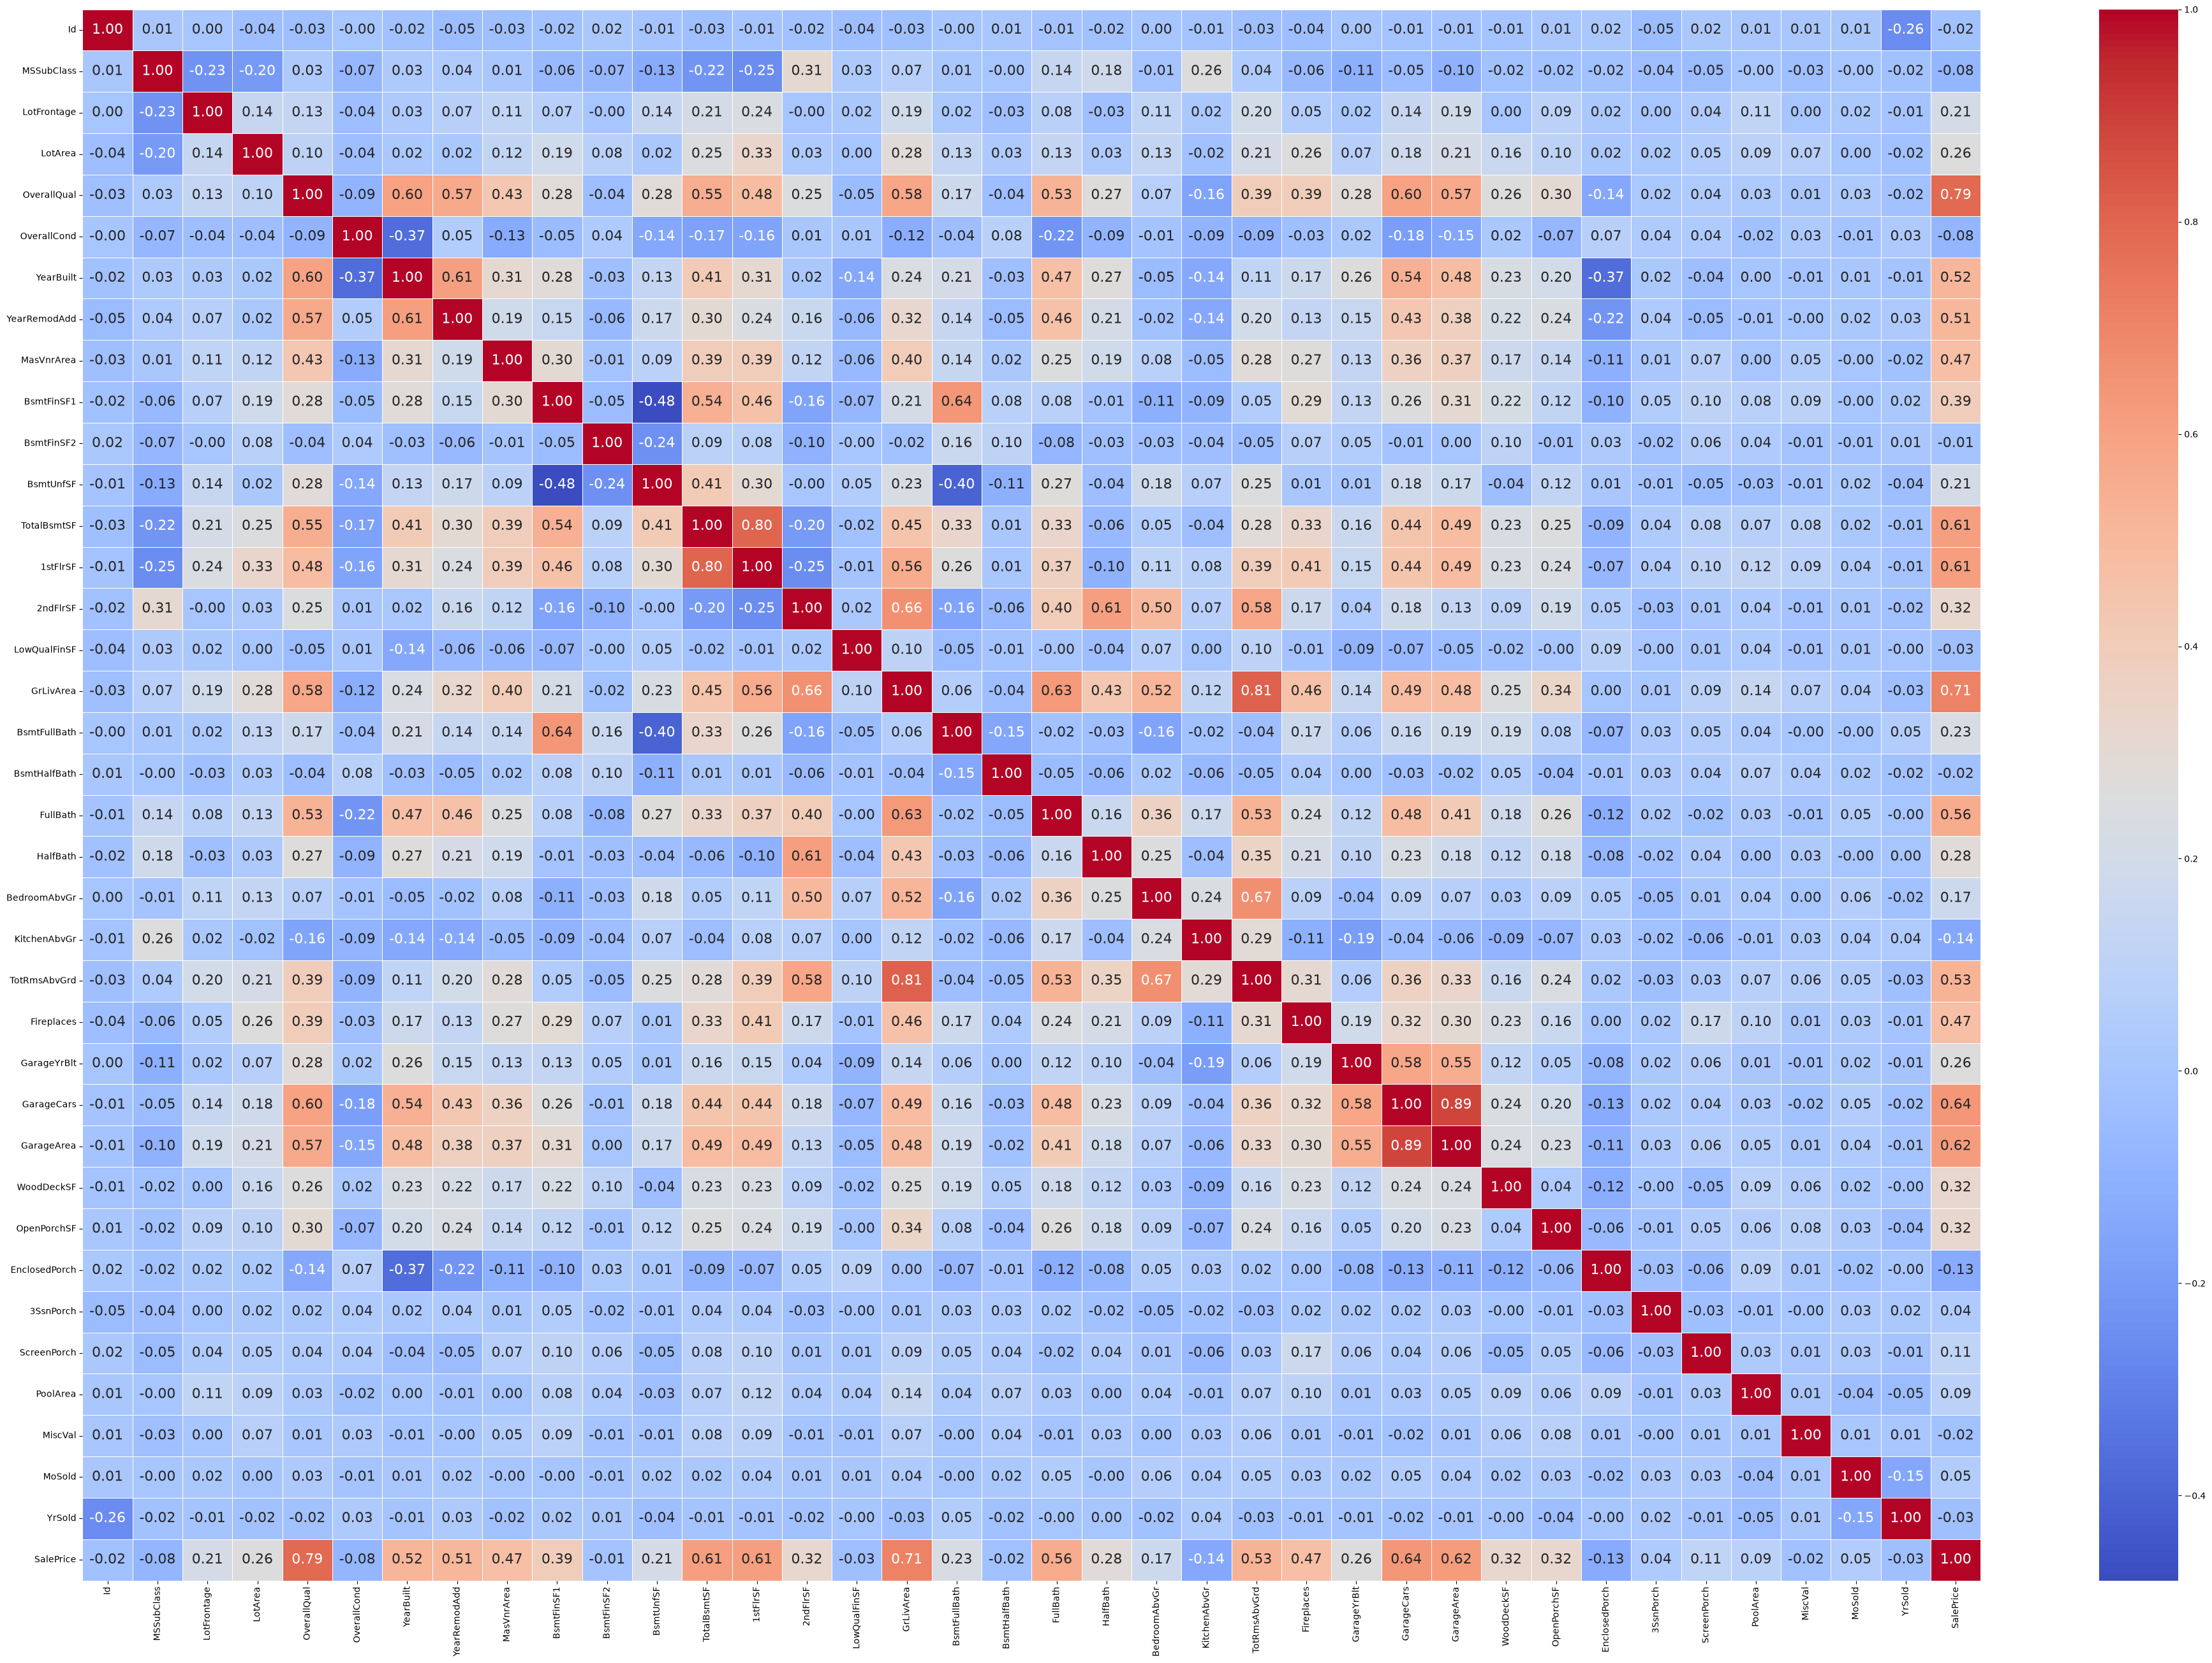

In [86]:
# Look up correlation between numeric features

# Select only numeric columns for calculating the correlation matrix
numeric_df = df.select_dtypes(include='number')

# Calculate the correlation matrix
df_corr = numeric_df.corr().round(2)

# Create a heatmap
plt.figure(figsize=(48, 32))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt="0.2f", linewidths=0.5, annot_kws={"size": 16})

plt.show()

In [87]:
# Features that have years in them
df['GarageYrBlt'] = df['YrSold'] - df['GarageYrBlt']
df['YearBuilt'] = df['YrSold'] - df['YearBuilt']
df['YearRemodAdd'] = df['YrSold'] - df['YearRemodAdd']

df.drop(['YrSold'], axis=1, inplace=True)
df.drop(['MoSold'], axis=1, inplace=True) #Isn't necessary

In [88]:
# Features that have square feet
df['BsmtFinSF'] = df['BsmtFinSF1'] + df['BsmtFinSF2']
df['TotalFlrSF'] = df['1stFlrSF'] + df['2ndFlrSF']

df.drop(['BsmtFinSF1'], axis=1, inplace=True)
df.drop(['BsmtFinSF2'], axis=1, inplace=True)
df.drop(['1stFlrSF'], axis=1, inplace=True)
df.drop(['2ndFlrSF'], axis=1, inplace=True)
df.drop(['TotalBsmtSF'], axis=1, inplace=True) # Isn't necessary since it's a sum of the other columns

In [89]:
# Features that are about bathrooms
df['TotalBaths'] = df['FullBath'] + (0.5*df['HalfBath']) + df['BsmtFullBath'] + (0.5*df['BsmtHalfBath'])

df.drop(['FullBath'], axis=1, inplace=True)
df.drop(['HalfBath'], axis=1, inplace=True)
df.drop(['BsmtFullBath'], axis=1, inplace=True)
df.drop(['BsmtHalfBath'], axis=1, inplace=True)

In [90]:
# Features about the garage
df['GarageAreaPerCar'] = df['GarageArea'] / df['GarageCars']

# Fill in any nulls from feature engineering
df['GarageAreaPerCar'].fillna(0, inplace=True)

df.drop(['GarageArea'], axis=1, inplace=True)
df.drop(['GarageCars'], axis=1, inplace=True)

In [91]:
df['GarageAreaPerCar']=df['GarageAreaPerCar'].fillna(0, inplace=True)

## Feature Transformation 

Feature transformation refers to the process of altering the features or variables in your dataset to make them more suitable for analysis or modeling. This transformation can involve various techniques to modify the distribution, scale, or relationships between the features. Feature transformation is a crucial step in data preprocessing, particularly in machine learning tasks, where the quality and characteristics of the input features significantly impact the performance of the models

In [92]:
# Create a list of the numerical data types after the feature engineering
numerical_cols = [cname for cname in df.columns 
                  if pd.api.types.is_numeric_dtype(df[cname]) 
                  and cname != 'SalePrice']

# Create new dataframe with the numerical columns
skew_df = pd.DataFrame(numerical_cols, columns=['Feature'])

# This finction used to compute the skewness of a dataset
skew_df['Skew'] = skew_df['Feature'].apply(lambda feature: scipy.stats.skew(df[feature]))

# Change Skew to a postive number
skew_df['Absolute Skew'] = skew_df['Skew'].apply(abs)

# Create true/false columns based on if Absolute Skew is >=0.5
skew_df['Skewed'] = skew_df['Absolute Skew'].apply(lambda x: True if x >= 0.5 else False)

In [93]:
skew_df

,Feature,Skew,Absolute Skew,Skewed
0,Id,0.000000,0.000000,False
1,MSSubClass,1.375457,1.375457,True
2,LotFrontage,0.022013,0.022013,False
3,LotArea,12.822431,12.822431,True
4,OverallQual,0.197110,0.197110,False
5,OverallCond,0.570312,0.570312,True
6,YearBuilt,0.598609,0.598609,True
7,YearRemodAdd,0.450226,0.450226,False
8,MasVnrArea,2.613592,2.613592,True
9,BsmtUnfSF,0.919339,0.919339,True


In [94]:
# Check if a column has a min of 0 for log transformation
df[numerical_cols].describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtUnfSF,LowQualFinSF,GrLivArea,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,BsmtFinSF,TotalFlrSF,TotalBaths,GarageAreaPerCar
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000
mean,1460.000000,57.137718,57.766701,10168.114080,6.089072,5.564577,36.479959,23.528263,101.396026,560.579993,4.694416,1500.759849,2.860226,1.044536,6.451524,0.597122,137.497088,93.709832,47.486811,23.098321,2.602261,16.062350,2.251799,50.825968,490.837273,1496.065433,2.218397,257.558056
std,842.787043,42.517628,33.481636,7886.996359,1.409947,1.113131,30.336182,20.892061,178.854579,439.590889,46.396825,506.051045,0.822693,0.214462,1.569379,0.646129,449.665870,126.526589,67.575493,64.244246,25.188169,56.184365,35.663946,567.402211,477.209821,503.675790,0.808840,86.049842
min,1.000000,20.000000,0.000000,1300.000000,1.000000,1.000000,-1.000000,-2.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,2.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,1.000000,0.000000
25%,730.500000,20.000000,43.000000,7478.000000,5.000000,5.000000,7.000000,4.000000,0.000000,220.000000,0.000000,1126.000000,2.000000,1.000000,5.000000,0.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1120.000000,1.500000,226.500000
50%,1460.000000,50.000000,63.000000,9453.000000,6.000000,5.000000,35.000000,15.000000,0.000000,467.000000,0.000000,1444.000000,3.000000,1.000000,6.000000,1.000000,30.000000,0.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,457.000000,1440.000000,2.000000,262.666667
75%,2189.500000,70.000000,78.000000,11570.000000,7.000000,6.000000,54.500000,43.000000,163.500000,805.000000,0.000000,1743.500000,3.000000,1.000000,7.000000,1.000000,51.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,805.500000,1742.500000,2.500000,294.000000
max,2919.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,136.000000,60.000000,1600.000000,2336.000000,1064.000000,5642.000000,8.000000,3.000000,15.000000,4.000000,2010.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,5644.000000,5642.000000,7.000000,924.000000


In [95]:
# Apply log1p transformation to df whose above a 0.5 absolute skew
for column in skew_df.query("Skewed == True")['Feature'].values:
    df[column] = np.log1p(df[column])
    

## Encoding Categorical

In [96]:
# Get list of numerical before starting
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('SalePrice')
num_cols = num_cols.drop('Id')

In [97]:
# Get list of categorical
categorical_columns_list = df.select_dtypes(include='object').columns

# Create a new Dataframe containing only the categorical columns
df_categorical = df[categorical_columns_list].copy()

df_categorical

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,No,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,None,Attchd,RFn,TA,TA,Y,None,None,None,WD,Normal
1,RL,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,Gable,CompShg,MetalSd,MetalSd,None,TA,TA,CBlock,Gd,TA,Gd,ALQ,Unf,GasA,Ex,Y,SBrkr,TA,Typ,TA,Attchd,RFn,TA,TA,Y,None,None,None,WD,Normal
2,RL,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,Mn,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,None,None,None,WD,Normal
3,RL,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,Gable,CompShg,Wd Sdng,Wd Shng,None,TA,TA,BrkTil,TA,Gd,No,ALQ,Unf,GasA,Gd,Y,SBrkr,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,None,None,None,WD,Abnorml
4,RL,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,Av,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,None,None,None,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,RM,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,Gable,CompShg,CemntBd,CmentBd,None,TA,TA,CBlock,TA,TA,No,Unf,Unf,GasA,Gd,Y,SBrkr,TA,Typ,None,None,None,None,None,Y,None,None,None,WD,Normal
2915,RM,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,Gable,CompShg,CemntBd,CmentBd,None,TA,TA,CBlock,TA,TA,No,Rec,Unf,GasA,TA,Y,SBrkr,TA,Typ,None,CarPort,Unf,TA,TA,Y,None,None,None,WD,Abnorml
2916,RL,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,None,TA,TA,CBlock,TA,TA,No,ALQ,Unf,GasA,Ex,Y,SBrkr,TA,Typ,TA,Detchd,Unf,TA,TA,Y,None,None,None,WD,Abnorml
2917,RL,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,SFoyer,Gable,CompShg,HdBoard,Wd Shng,None,TA,TA,PConc,Gd,TA,Av,GLQ,Unf,GasA,TA,Y,SBrkr,TA,Typ,None,None,None,None,None,Y,None,MnPrv,Shed,WD,Normal


The label encoder method was giving me undesirable values, for example "None" could of been a 4, so going to do it manually

In [98]:
# Label encode all the ordinal data

ordinal_1 = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 
                 'GarageQual', 'GarageCond', 'PoolQC']

for col in ordinal_1:
    if 'None' in df[col].value_counts().index:
        df[col] = df[col].map({"None":0,"Po":1,"Fa":2,"TA":3,"Gd":4,"Ex":5}).astype('int')
    else:
        df[col] = df[col].map({"Po":1,"Fa":2,"TA":3,"Gd":4,"Ex":5}).astype('int')

In [99]:
# Label encode all the ordinal data individually, and add to list

ordinal_2 = ['LotShape', 'LandContour', 'LandSlope', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
                 'Utilities', 'CentralAir', 'Functional', 'GarageFinish', 'PavedDrive', 'Fence']

df['LotShape'] = df['LotShape'].map({"None":0,"IR3":1,"IR2":2,"IR1":3,"Reg":4}).astype('int')
df['LandContour'] = df['LandContour'].map({"None":0,"Low":1,"Bnk":2,"HLS":3,"Lvl":4}).astype('int')
df['LandSlope'] = df['LandSlope'].map({"None":0,"Sev":1,"Mod":2,"Gtl":3}).astype('int')
df['BsmtExposure'] = df['BsmtExposure'].map({"None":0, "No":1,"Mn":2,"Av":3,"Gd":4}).astype('int')
df['BsmtFinType1'] = df['BsmtFinType1'].map({"None":0, "Unf":1,"LwQ":2,"Rec":3,"BLQ":4,"ALQ":5,"GLQ":6}).astype('int')
df['BsmtFinType2'] = df['BsmtFinType2'].map({"None":0, "Unf":1,"LwQ":2,"Rec":3,"BLQ":4,"ALQ":5,"GLQ":6}).astype('int')
df['Utilities'] = df['Utilities'].map({"None":0,"ELO":1,"NoSeWa":2,"NoSewr":3,"AllPub":4}).astype('int')
df['CentralAir'] = df['CentralAir'].map({"None":0,"N":1,"Y":2}).astype('int')
df['Functional'] = df['Functional'].map({"None":0,"Sal":1,"Sev":2,"Maj2":3,"Maj1":4,"Mod":5,"Min2":6,
                                         "Min1":7,"Typ":8}).astype('int')
df['GarageFinish'] = df['GarageFinish'].map({"None":0,"Unf":1,"RFn":2,"Fin":3}).astype('int')
df['PavedDrive'] = df['PavedDrive'].map({"None":0,"N":1,"P":2,"Y":3}).astype('int')
df['Fence'] = df['Fence'].map({"None":0, "MnWw":1,"GdWo":2,"MnPrv":3,"GdPrv":4}).astype('int')

In [100]:
# Get remaining non-ordinal categorical columns
df_categorical = df_categorical.drop(columns=ordinal_1)
df_categorical = df_categorical.drop(columns=ordinal_2)

# Get the rest of the categorical data for one hot encoding
ohe_ = df_categorical.columns.tolist()

# Convert categorical columns to one-hot encoded columns, dropping the first column for each
df_encoded = pd.get_dummies(df[ohe_], drop_first=True).astype(int)

# Concatenate the one-hot encoded columns with the original Dataframe
df = pd.concat([df.drop(columns=ohe_), df_encoded], axis=1)

Split Train and Test Data

In [101]:
# Split the data back into train and test sets
train = df.iloc[:train.shape[0]]
test = df.iloc[train.shape[0]:]

train.drop(['Id'], axis=1, inplace=True)
test.drop(['SalePrice', 'Id'], axis=1, inplace=True)

## Target Feature Encoding

Perform log transformation on SalePrice so it's less skewed

In [102]:
log_target = np.log(train['SalePrice'])

train.drop(['SalePrice'], axis=1, inplace=True)

## Optuna Parameters

In [103]:
#Define objective function for Optuna for catboost
def objective_cat(trial):
    #Define hyperparameters to optimize
     catboost_params = {
         'iterations': trial.suggest_int('iterations', 1000, 8000),
         'learning_rate': trial.suggest_loguniform('learning_rate', 0.005, 0.08),
         'depth': trial.suggest_int('depth', 3, 7),
         'eval_metric': 'RMSE',
     }

# Initialize models with suggested parameters
     catboost_model = CatBoostRegressor(**catboost_params, verbose=0)
    
# Train models
     catboost_model.fit(train, log_target)

# Calculate RMSE
     kf = KFold(n_splits=10)
     catboost_rmse = np.exp(np.sqrt(-cross_val_score(catboost_model,train, log_target, scoring='neg_mean_squared_error', cv=kf)))

# Return average RMSE
     return np.mean(catboost_rmse)

In [104]:
# # Define objective function for Optuna for xgboost
def objective_xgb(trial):
#     # Define hyperparameters to optimize
    xgboost_params = {
         'n_estimators': trial.suggest_int('n_estimators', 1000, 8000),
         'learning_rate': trial.suggest_loguniform('learning_rate', 0.005, 0.08),
         'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.2, 0.6),
         'subsample': trial.suggest_uniform('subsample', 0.4, 0.8),
         'min_child_weight': trial.suggest_int('min_child_weight', 2, 5),
     }

     # Initialize models with suggested parameters
    xgb_model = XGBRegressor(**xgboost_params, verbosity=0)

     # Train models
    xgb_model.fit(train, log_target)

     # Calculate RMSE
    kf = KFold(n_splits=10)
    xgb_rmse = np.exp(np.sqrt(-cross_val_score(xgb_model, train, log_target, scoring='neg_mean_squared_error', cv=kf)))

     # Return average RMSE
    return np.mean(xgb_rmse)

In [105]:
# Optimize hyperparameters catboost
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=25)

[I 2026-07-10 09:02:07,721] A new study created in memory with name: no-name-ab53ab3f-29ec-4663-8f82-fc7e6f550963
[I 2026-07-10 09:04:22,455] Trial 0 finished with value: 1.1288835361058724 and parameters: {'iterations': 7907, 'learning_rate': 0.046603966978025296, 'depth': 4}. Best is trial 0 with value: 1.1288835361058724.
[I 2026-07-10 09:06:01,957] Trial 1 finished with value: 1.128686436612559 and parameters: {'iterations': 3331, 'learning_rate': 0.005157033527330881, 'depth': 6}. Best is trial 1 with value: 1.128686436612559.
[I 2026-07-10 09:07:51,737] Trial 2 finished with value: 1.1295401129888845 and parameters: {'iterations': 7418, 'learning_rate': 0.050229949230785914, 'depth': 4}. Best is trial 1 with value: 1.128686436612559.
[I 2026-07-10 09:11:33,171] Trial 3 finished with value: 1.1265288095253978 and parameters: {'iterations': 7889, 'learning_rate': 0.008517347258013236, 'depth': 6}. Best is trial 3 with value: 1.1265288095253978.
[I 2026-07-10 09:14:01,144] Trial 4 f

In [106]:
 # Optimize hyperparameters xgboost
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=25)

[I 2026-07-10 09:57:56,203] A new study created in memory with name: no-name-01efcd5f-923a-4b67-a24d-6a147c94204d
[I 2026-07-10 09:59:03,085] Trial 0 finished with value: 1.1301848835577608 and parameters: {'n_estimators': 4491, 'learning_rate': 0.055073016549126996, 'colsample_bytree': 0.24434739633211283, 'subsample': 0.45224530532006524, 'min_child_weight': 3}. Best is trial 0 with value: 1.1301848835577608.
[I 2026-07-10 09:59:27,578] Trial 1 finished with value: 1.1290907831446686 and parameters: {'n_estimators': 1530, 'learning_rate': 0.006093235994067249, 'colsample_bytree': 0.20492906794145851, 'subsample': 0.7851491843645703, 'min_child_weight': 4}. Best is trial 1 with value: 1.1290907831446686.
[I 2026-07-10 10:00:01,916] Trial 2 finished with value: 1.1313134688674222 and parameters: {'n_estimators': 2171, 'learning_rate': 0.0756329789472679, 'colsample_bytree': 0.39100581003822743, 'subsample': 0.5342902910349916, 'min_child_weight': 5}. Best is trial 1 with value: 1.12909

In [108]:
study_cat

In [114]:
study_cat.best_value


1.1258702687393936

In [116]:
study_xgb.best_value

1.1259527182854563

## Forming and Testing the Model


In [117]:
best_params_cat = {
    'iterations': 6623,
    'learning_rate': 0.01711,
    'depth': 5,
    'eval_metric':'RMSE',
}

best_params_xgb = {
    'n_estimators': 6696,
    'learning_rate': 0.00630,
    'colsample_bytree': 0.22301,
    'subsample': 0.45878,
    'min_child_weight': 3,
}

In [119]:
# Use best parameters to train final models
catboost_model = CatBoostRegressor(**best_params_cat, verbose=0)
xgb_model = XGBRegressor(**best_params_xgb, verbosity=0)

catboost_model.fit(train, log_target)
xgb_model.fit(train, log_target)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.22301
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [121]:
# Calculate RMSE CatBoost
kf = KFold(n_splits=10)
catboost_rmse = np.exp(np.sqrt(-cross_val_score(catboost_model, train, log_target, scoring='neg_mean_squared_error', cv=kf)))

In [123]:
xgb_rmse = np.exp(np.sqrt(-cross_val_score(xgb_model,train, log_target, scoring='neg_mean_squared_error', cv=kf)))

In [125]:
# Return average RMSE
print(np.mean(catboost_rmse))
print(np.mean(xgb_rmse))

1.126165250044916
1.1269357335009562


In [126]:
# Combine predictions
final_predictions = (
    0.80 * np.exp(catboost_model.predict(test)) + 
    0.20 * np.exp(xgb_model.predict(test))
)

## Submission

In [128]:
# Save test predictions to file
output = pd.DataFrame({'Id': test.index+1, 'SalePrice': final_predictions})
output.to_csv('submission.csv', index=False)

In [129]:
output

,Id,SalePrice
0,1461,113269.327857
1,1462,163974.074707
2,1463,185941.847165
3,1464,196024.919467
4,1465,188636.840938
...,...,...
1454,2915,82873.016643
1455,2916,77693.024387
1456,2917,156264.074253
1457,2918,115008.585017
